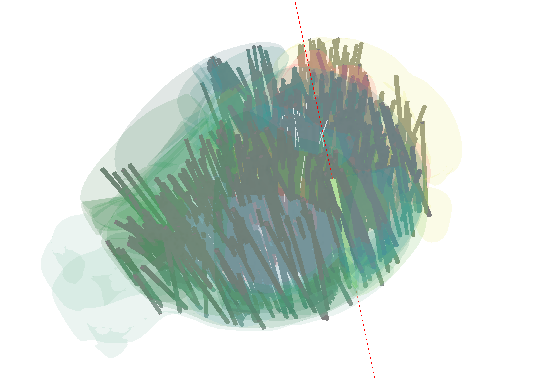

In [ ]:
# Change kernel (on the right-top of Jupyter lab) to 'Python (ibl)'
# Alyx password for "intbrainlab" is: international
# Find an eid: https://viz.internationalbrainlab.org/app?spikesorting=ss_2024-05-06

from pathlib import Path

from one.api import ONE

CACHE_DIR = Path('G:/academic/ONE')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
one = ONE(base_url='https://openalyx.internationalbrainlab.org', cache_dir=CACHE_DIR, mode='remote')

eid0 = 'e5c75b62-6871-4135-b3d0-f6464c2d90c0'  # pid: aac3b928-e99a-4039-ace1-af45d0130d82
trials0 = one.load_object(eid0, 'trials', collection='alf', namespace='ibl')


## Raw data check
The 	rials0 object loaded above is ALF behavioral data, not raw continuous ephys. The session may still contain raw SpikeGLX AP files under aw_ephys_data; the cell below checks for those files without downloading the large binaries.


In [ ]:
from pathlib import PurePosixPath

datasets = one.list_datasets(eid0, details=True, query_type='remote', keep_eid_index=True)
rel = datasets['rel_path'].astype(str)

trials_rows = datasets.loc[rel.str.contains(r'(?:^|/)_(?:ibl_)?trials\.', regex=True), ['rel_path', 'file_size']].copy()
raw_ap_rows = datasets.loc[
    rel.str.contains(r'^raw_ephys_data/probe\d+/', regex=True)
    & rel.str.contains(r'\.ap\.(?:cbin|bin|meta|ch)$', regex=True),
    ['rel_path', 'file_size']
].copy()
raw_ap_rows['file_size_GB'] = raw_ap_rows['file_size'] / 1e9

CURRENT_OBJECT_IS_RAW = False
SESSION_HAS_RAW_AP = len(raw_ap_rows) > 0

print('trials0 type:', type(trials0))
print('Current loaded object is raw continuous ephys:', CURRENT_OBJECT_IS_RAW)
print('Session has raw AP files available:', SESSION_HAS_RAW_AP)
display(raw_ap_rows.sort_values('rel_path'))


## IBL kernel: optional raw AP download and conversion
Run this section in the Python (ibl) kernel. OpenAlyx provides AP raw data for this session as compressed SpikeGLX .ap.cbin files. Kilosort4 should be run on an int16 .ap.bin, so this section can download the .cbin/.meta/.ch files and decompress the selected probe. The default flags are False because each AP file is tens of GB and the decompressed .bin will require additional disk space.


In [ ]:
from pathlib import Path, PurePosixPath
import json

PROBE = 'probe00'
RUN_RAW_DOWNLOAD = True
RUN_CBIN_DECOMPRESS = True

probe_rows = raw_ap_rows[raw_ap_rows['rel_path'].astype(str).str.contains(f'raw_ephys_data/{PROBE}/')].copy()
display(probe_rows.sort_values('rel_path'))

def expected_local_path(rel_path):
    """Return the normal ONE cache path for this relative dataset path."""
    rel_path = PurePosixPath(str(rel_path))
    hits = sorted(CACHE_DIR.glob(f'**/{rel_path.as_posix()}'))
    if hits:
        return hits[0]
    return CACHE_DIR / rel_path

def file_status(path, expected_size=None):
    path = Path(path)
    if not path.exists():
        return {'path': str(path), 'status': 'missing', 'size': 0, 'expected_size': expected_size}
    size = path.stat().st_size
    if expected_size and size == int(expected_size):
        status = 'complete'
    elif expected_size and size < int(expected_size):
        status = 'partial'
    elif expected_size and size > int(expected_size):
        status = 'size_mismatch_large'
    else:
        status = 'exists_unverified'
    return {'path': str(path), 'status': status, 'size': size, 'expected_size': expected_size}

def load_rel_path(eid, rel_path):
    rel_path = PurePosixPath(str(rel_path))
    return Path(one.load_dataset(
        eid,
        rel_path.name,
        collection=str(rel_path.parent),
        query_type='remote',
        download_only=True,
    ))

def ensure_dataset_downloaded(eid, row):
    rel_path = str(row['rel_path'])
    expected_size = int(row['file_size']) if row.get('file_size') else None
    target = expected_local_path(rel_path)
    before = file_status(target, expected_size)

    if before['status'] == 'complete':
        print('already complete:', target)
        return {**before, 'rel_path': rel_path, 'action': 'skipped_complete'}

    if before['status'] == 'partial':
        print('partial file found; continuing download/check:', target, before['size'], '/', expected_size)
    elif before['status'] == 'missing':
        print('missing file; starting download:', rel_path)
    else:
        print('existing file needs verification/redownload:', before)

    path = load_rel_path(eid, rel_path)
    after = file_status(path, expected_size)
    if after['status'] != 'complete':
        print('warning: file is still not complete after download attempt:', after)
    else:
        print('complete:', path)
    return {**after, 'rel_path': rel_path, 'action': 'downloaded_or_resumed', 'before': before}

download_records = []
downloaded_paths = []
if RUN_RAW_DOWNLOAD:
    needed_rows = probe_rows.sort_values('rel_path')
    if needed_rows.empty:
        raise RuntimeError(f'No AP raw files found for {PROBE}')
    for _, row in needed_rows.iterrows():
        record = ensure_dataset_downloaded(eid0, row)
        download_records.append(record)
        downloaded_paths.append(record['path'])
else:
    print('RUN_RAW_DOWNLOAD is False; raw AP files were not downloaded.')
    for _, row in probe_rows.sort_values('rel_path').iterrows():
        target = expected_local_path(row['rel_path'])
        download_records.append({**file_status(target, int(row['file_size'])), 'rel_path': str(row['rel_path']), 'action': 'checked_only'})

existing_cbin = sorted(CACHE_DIR.glob(f'**/raw_ephys_data/{PROBE}/*.ap.cbin'))
print('local .ap.cbin candidates:', existing_cbin)

ap_bin = None
decompress_record = {'action': 'not_requested', 'ap_bin': None}
if RUN_CBIN_DECOMPRESS:
    if not existing_cbin:
        raise FileNotFoundError('No local .ap.cbin found. Set RUN_RAW_DOWNLOAD=True first.')
    import spikeglx
    cbin = existing_cbin[0]
    reader = spikeglx.Reader(cbin)
    target_bin = cbin.with_suffix('.bin')
    expected_bin_size = int(reader.ns * reader.nc * reader.dtype.itemsize)
    before_bin = file_status(target_bin, expected_bin_size)

    if before_bin['status'] == 'complete':
        ap_bin = target_bin
        decompress_record = {**before_bin, 'action': 'skipped_complete'}
        print('decompressed AP bin already complete:', ap_bin)
    else:
        if before_bin['status'] == 'partial':
            print('partial decompressed .ap.bin found. mtscomp cannot append-resume decompression; overwriting this incomplete .bin:', before_bin)
        else:
            print('decompressing .ap.cbin to .ap.bin:', cbin)
        ap_bin = Path(reader.decompress_file(keep_original=True, out=target_bin, overwrite=True))
        after_bin = file_status(ap_bin, expected_bin_size)
        decompress_record = {**after_bin, 'action': 'decompressed_overwrite_if_needed', 'before': before_bin}
        if after_bin['status'] != 'complete':
            raise RuntimeError(f'Decompressed AP bin is not complete: {after_bin}')
        print('decompressed AP bin complete:', ap_bin)
else:
    print('RUN_CBIN_DECOMPRESS is False; no .ap.bin was created.')

manifest = {
    'eid': eid0,
    'probe': PROBE,
    'cache_dir': str(CACHE_DIR),
    'downloaded_paths': downloaded_paths,
    'download_records': download_records,
    'local_cbin_candidates': [str(p) for p in existing_cbin],
    'ap_bin': str(ap_bin) if ap_bin else None,
    'decompress_record': decompress_record,
}
manifest_path = Path('G:/academic/week8_raw_ap_manifest.json')
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print('manifest:', manifest_path)


## Kilosort4 kernel: run sorting on decompressed AP binary
After the .ap.bin exists, switch this notebook to the Kilosort4 kernel before running the cell below. The Kilosort4 environment does not include the IBL decompression stack, so only run this cell after the previous section has produced an int16 .ap.bin.


Memory note: for high-spike-count recordings, Kilosort4's temporal feature array has shape `n_spikes x nearest_chans x n_pcs`. The notebook now defaults to low-memory settings (`nearest_chans=2`, `n_pcs=2`, `save_extra_vars=False`) to avoid multi-GB allocations such as `(32000000, 10, 6)`. Increase these only if you have enough RAM and need richer Phy PC features.


In [ ]:
from pathlib import Path

RUN_KILOSORT4 = True
PROBE = 'probe00'
ROOT = Path('G:/academic')
CACHE_DIR = ROOT / 'ONE'
RESULTS_DIR = ROOT / 'week8_kilosort4' / PROBE

# Low-memory defaults. The large array is approximately
# n_spikes * nearest_chans * n_pcs * 4 bytes, before extra temporary copies.
KS_NEAREST_CHANS = 2
KS_N_PCS = 2
SAVE_EXTRA_VARS = False
CLEAR_CACHE = True

ap_bin_candidates = sorted(CACHE_DIR.glob(f'**/raw_ephys_data/{PROBE}/*.ap.bin'))
print('AP bin candidates:', ap_bin_candidates)


def estimate_feature_memory_gib(n_spikes, nearest_chans=KS_NEAREST_CHANS, n_pcs=KS_N_PCS):
    return int(n_spikes) * int(nearest_chans) * int(n_pcs) * 4 / 1024**3


if RUN_KILOSORT4:
    if not ap_bin_candidates:
        raise FileNotFoundError('No decompressed .ap.bin found. Run the IBL-kernel download/decompress cell first.')

    AP_BIN = ap_bin_candidates[0]
    settings = {
        'filename': AP_BIN,
        'n_chan_bin': 385,
        'fs': 30000,
        'nearest_chans': KS_NEAREST_CHANS,
        'n_pcs': KS_N_PCS,
    }

    print('Low-memory Kilosort settings:', settings)
    print('Feature memory estimate for 32M spikes:', f'{estimate_feature_memory_gib(32_000_000):.2f} GiB')
    print('SAVE_EXTRA_VARS:', SAVE_EXTRA_VARS)

    from kilosort import run_kilosort
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    ks_output = run_kilosort(
        settings=settings,
        probe_name='NeuroPix1_default.mat',
        results_dir=RESULTS_DIR,
        data_dtype='int16',
        save_extra_vars=SAVE_EXTRA_VARS,
        clear_cache=CLEAR_CACHE,
        verbose_console=True,
    )
    print('Kilosort4 output directory:', RESULTS_DIR)
else:
    if ap_bin_candidates:
        print('RUN_KILOSORT4 is False; set it to True to run Kilosort4 on:', ap_bin_candidates[0])
    else:
        print('RUN_KILOSORT4 is False and no .ap.bin is present yet. Decompress the selected .ap.cbin in the IBL kernel first.')


## Reusable Kilosort4 run for another EID/PID

Use the cells below for additional sessions. Edit only `NEW_EID`, or set `NEW_PID` and leave `NEW_EID = None`. Each run writes to a separate timestamped folder under `G:/academic/week8_kilosort4_runs`, so previous Kilosort results are not overwritten.

Run order:

1. Run the setup/check cell in the IBL kernel.
2. Run the download/decompress cell in the IBL kernel.
3. Switch to the Kilosort4 kernel and run the sorting cell.


|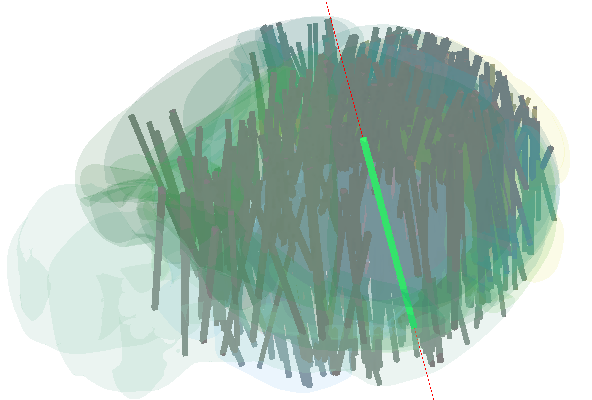|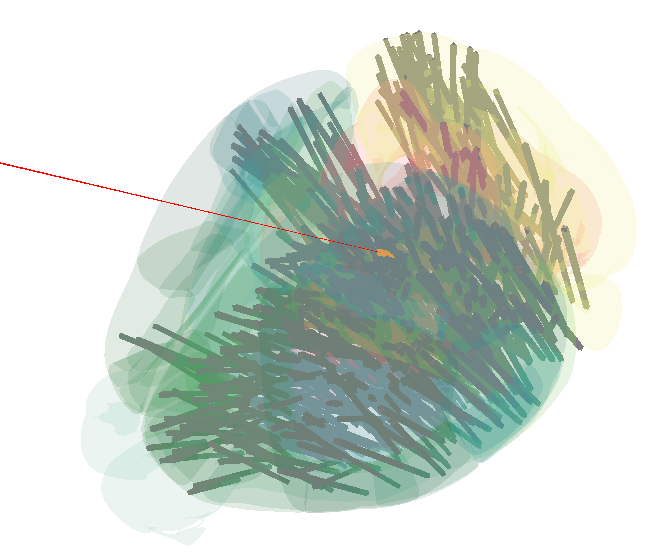|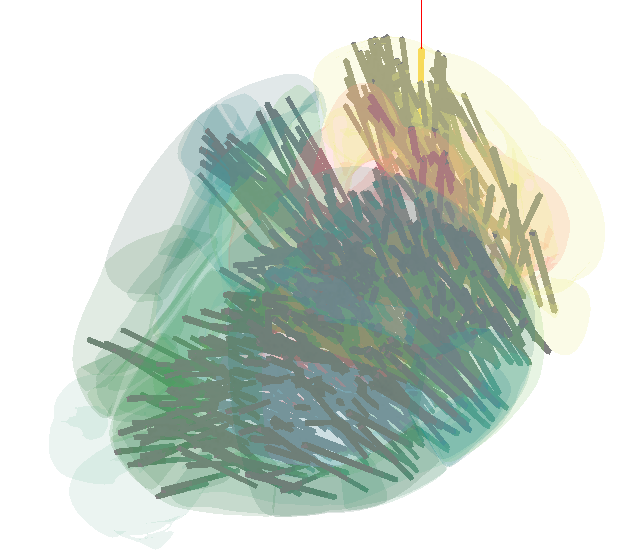|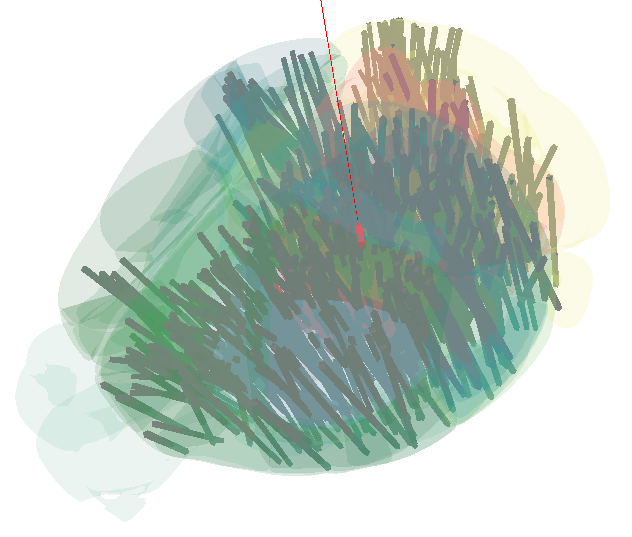|
|---|---|---|---|
|cde63527-7f5a-4cc3-8ac2-215d82e7da26|bb099402-fb31-4cfd-824e-1c97530a0875|9545aa05-3945-4054-a5c3-a259f7209d61|4fa70097-8101-4f10-b585-db39429c5ed0|

In [1]:
# IBL kernel: configure a new dataset and inspect available raw AP files.
from pathlib import Path, PurePosixPath
from datetime import datetime
import json
import re

from one.api import ONE

ROOT = Path('G:/academic')
CACHE_DIR = ROOT / 'ONE'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
one = ONE(base_url='https://openalyx.internationalbrainlab.org', cache_dir=CACHE_DIR, mode='remote')

# Edit these values for a new dataset.
NEW_EID = '4fa70097-8101-4f10-b585-db39429c5ed0'
NEW_PID = None
NEW_PROBE = 'probe00'

# Optional run label. Leave as None to auto-generate from EID/probe/time.
RUN_LABEL = None
RUN_ROOT = ROOT / 'week8_kilosort4_runs'
RUN_ROOT.mkdir(parents=True, exist_ok=True)

if NEW_EID is None:
    if not NEW_PID:
        raise ValueError('Set NEW_EID, or set NEW_PID and leave NEW_EID = None.')
    NEW_EID, probe_from_pid = one.pid2eid(NEW_PID)
    if NEW_PROBE is None:
        NEW_PROBE = probe_from_pid

NEW_EID = str(NEW_EID)
NEW_PROBE = str(NEW_PROBE)
run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
eid_short = NEW_EID.split('-')[0]
run_label = RUN_LABEL or f'{eid_short}_{NEW_PROBE}_{run_stamp}'
RUN_DIR = RUN_ROOT / run_label

print('NEW_EID:', NEW_EID)
print('NEW_PID:', NEW_PID)
print('NEW_PROBE:', NEW_PROBE)
print('RUN_DIR:', RUN_DIR)

datasets_new = one.list_datasets(NEW_EID, details=True, query_type='remote', keep_eid_index=True)
rel_new = datasets_new['rel_path'].astype(str)
raw_ap_rows_new = datasets_new.loc[
    rel_new.str.contains(rf'^raw_ephys_data/{re.escape(NEW_PROBE)}/', regex=True)
    & rel_new.str.contains(r'\.ap\.(?:cbin|bin|meta|ch)$', regex=True),
    ['rel_path', 'file_size']
].copy()
raw_ap_rows_new['file_size_GB'] = raw_ap_rows_new['file_size'] / 1e9

if raw_ap_rows_new.empty:
    display(datasets_new[['rel_path', 'file_size']].head(30))
    raise RuntimeError(f'No raw AP files found for {NEW_EID} / {NEW_PROBE}. Check NEW_PROBE or choose another EID/PID.')

display(raw_ap_rows_new.sort_values('rel_path'))


NEW_EID: 4fa70097-8101-4f10-b585-db39429c5ed0
NEW_PID: None
NEW_PROBE: probe00
RUN_DIR: G:\academic\week8_kilosort4_runs\4fa70097_probe00_20260708_145454


rel_path  \
eid                                  id                                                                                        
4fa70097-8101-4f10-b585-db39429c5ed0 e382cdc8-994a-48ef-8754-c30cd7c2ecbf  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   
                                     f8d0d33f-138c-4ce1-a7ec-36c425cbdbfc  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   
                                     a309888c-1176-44b7-8990-d872c2f8f4cb  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   

                                                                             file_size  \
eid                                  id                                                  
4fa70097-8101-4f10-b585-db39429c5ed0 e382cdc8-994a-48ef-8754-c30cd7c2ecbf  31075513422   
                                     f8d0d33f-138c-4ce1-a7ec-36c425cbdbfc       113117   
                                     a309888c-1176-44b7-8990-d872c2f8f4cb        17754   

                                                                           file_size_GB  
eid                                  id                                                  
4fa70097-8101-4f10-b585-db39429c5ed0 e382cdc8-994a-48ef-8754-c30cd7c2ecbf     31.075513  
                                     f8d0d33f-138c-4ce1-a7ec-36c425cbdbfc      0.000113  
                                     a309888c-1176-44b7-8990-d872c2f8f4cb      0.000018

### IBL kernel: download and decompress raw AP

This cell resumes existing complete or partial downloads where possible. It decompresses the selected `.ap.cbin` into `.ap.bin` in the normal ONE cache. The Kilosort output is still saved separately in `RUN_DIR`.


In [2]:
# IBL kernel: download selected probe raw AP files and decompress .ap.cbin to .ap.bin.
from pathlib import Path, PurePosixPath
import json

RUN_NEW_RAW_DOWNLOAD = True
RUN_NEW_CBIN_DECOMPRESS = True


def expected_local_path_new(rel_path):
    rel_path = PurePosixPath(str(rel_path))
    hits = sorted(CACHE_DIR.glob(f'**/{rel_path.as_posix()}'))
    if hits:
        return hits[0]
    return CACHE_DIR / rel_path


def file_status_new(path, expected_size=None):
    path = Path(path)
    if not path.exists():
        return {'path': str(path), 'status': 'missing', 'size': 0, 'expected_size': expected_size}
    size = path.stat().st_size
    if expected_size and size == int(expected_size):
        status = 'complete'
    elif expected_size and size < int(expected_size):
        status = 'partial'
    elif expected_size and size > int(expected_size):
        status = 'size_mismatch_large'
    else:
        status = 'exists_unverified'
    return {'path': str(path), 'status': status, 'size': size, 'expected_size': expected_size}


def load_rel_path_new(eid, rel_path):
    rel_path = PurePosixPath(str(rel_path))
    return Path(one.load_dataset(
        eid,
        rel_path.name,
        collection=str(rel_path.parent),
        query_type='remote',
        download_only=True,
    ))


def ensure_dataset_downloaded_new(eid, row):
    rel_path = str(row['rel_path'])
    expected_size = int(row['file_size']) if row.get('file_size') else None
    target = expected_local_path_new(rel_path)
    before = file_status_new(target, expected_size)

    if before['status'] == 'complete':
        print('already complete:', target)
        return {**before, 'rel_path': rel_path, 'action': 'skipped_complete'}

    if before['status'] == 'partial':
        print('partial file found; continuing download/check:', target, before['size'], '/', expected_size)
    elif before['status'] == 'missing':
        print('missing file; starting download:', rel_path)
    else:
        print('existing file needs verification/redownload:', before)

    path = load_rel_path_new(eid, rel_path)
    after = file_status_new(path, expected_size)
    if after['status'] != 'complete':
        print('warning: file is still not complete after download attempt:', after)
    else:
        print('complete:', path)
    return {**after, 'rel_path': rel_path, 'action': 'downloaded_or_resumed', 'before': before}


download_records_new = []
if RUN_NEW_RAW_DOWNLOAD:
    for _, row in raw_ap_rows_new.sort_values('rel_path').iterrows():
        download_records_new.append(ensure_dataset_downloaded_new(NEW_EID, row))
else:
    print('RUN_NEW_RAW_DOWNLOAD is False; checking local cache only.')
    for _, row in raw_ap_rows_new.sort_values('rel_path').iterrows():
        target = expected_local_path_new(row['rel_path'])
        download_records_new.append({**file_status_new(target, int(row['file_size'])), 'rel_path': str(row['rel_path']), 'action': 'checked_only'})

def local_paths_for_current_raw_rows(extension):
    paths = []
    for _, row in raw_ap_rows_new.sort_values('rel_path').iterrows():
        rel_path = str(row['rel_path'])
        if rel_path.endswith(extension):
            status = file_status_new(expected_local_path_new(rel_path), int(row['file_size']))
            if status['status'] in {'complete', 'exists_unverified'}:
                paths.append(Path(status['path']))
            else:
                matching_records = [record for record in download_records_new if record['rel_path'] == rel_path]
                paths.extend(Path(record['path']) for record in matching_records if Path(record['path']).exists())
    return sorted(set(paths))

local_cbin_candidates = local_paths_for_current_raw_rows('.ap.cbin')
print('local .ap.cbin candidates for current EID/probe:', local_cbin_candidates)

AP_BIN_NEW = None
decompress_record_new = {'action': 'not_requested', 'ap_bin': None}
if RUN_NEW_CBIN_DECOMPRESS:
    if not local_cbin_candidates:
        raise FileNotFoundError('No local .ap.cbin found for the current EID/probe. Set RUN_NEW_RAW_DOWNLOAD=True first.')
    import spikeglx
    cbin = local_cbin_candidates[0]
    reader = spikeglx.Reader(cbin)
    target_bin = cbin.with_suffix('.bin')
    expected_bin_size = int(reader.ns * reader.nc * reader.dtype.itemsize)
    before_bin = file_status_new(target_bin, expected_bin_size)

    if before_bin['status'] == 'complete':
        AP_BIN_NEW = target_bin
        decompress_record_new = {**before_bin, 'action': 'skipped_complete'}
        print('decompressed .ap.bin already complete:', AP_BIN_NEW)
    else:
        print('decompressing/resuming by overwriting incomplete target:', target_bin)
        reader.decompress_file(keep_original=True, out=target_bin, overwrite=True)
        after_bin = file_status_new(target_bin, expected_bin_size)
        if after_bin['status'] != 'complete':
            raise RuntimeError(f'Decompressed .ap.bin is not complete: {after_bin}')
        AP_BIN_NEW = target_bin
        decompress_record_new = {**after_bin, 'action': 'decompressed'}
        print('decompressed .ap.bin complete:', AP_BIN_NEW)
else:
    local_bin_candidates = [path.with_suffix('.bin') for path in local_paths_for_current_raw_rows('.ap.cbin') if path.with_suffix('.bin').exists()]
    if local_bin_candidates:
        AP_BIN_NEW = local_bin_candidates[0]
        print('using existing .ap.bin for current EID/probe:', AP_BIN_NEW)
    else:
        print('RUN_NEW_CBIN_DECOMPRESS is False and no .ap.bin was found for the current EID/probe.')

RUN_DIR.mkdir(parents=True, exist_ok=True)
run_info = {
    'eid': NEW_EID,
    'pid': NEW_PID,
    'probe': NEW_PROBE,
    'run_label': run_label,
    'run_dir': str(RUN_DIR),
    'ap_bin': str(AP_BIN_NEW) if AP_BIN_NEW else None,
    'download_records': download_records_new,
    'decompress_record': decompress_record_new,
}
run_info_path = RUN_DIR / 'run_info_download.json'
run_info_path.write_text(json.dumps(run_info, indent=2), encoding='utf-8')
print('saved download/decompress run info:', run_info_path)


existing file needs verification/redownload: {'path': 'G:\\academic\\ONE\\cortexlab\\Subjects\\KS043\\2020-12-07\\001\\raw_ephys_data\\probe00\\_spikeglx_ephysData_g0_t0.imec0.ap.cbin', 'status': 'size_mismatch_large', 'size': 35529098643, 'expected_size': 31075513422}


(S3) G:\academic\ONE\danlab\Subjects\DY_010\2020-01-21\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.cbin: 100%|██████████| 31.1G/31.1G [31:25<00:00, 16.5MB/s]  


complete: G:\academic\ONE\danlab\Subjects\DY_010\2020-01-21\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.cbin
existing file needs verification/redownload: {'path': 'G:\\academic\\ONE\\cortexlab\\Subjects\\KS043\\2020-12-07\\001\\raw_ephys_data\\probe00\\_spikeglx_ephysData_g0_t0.imec0.ap.ch', 'status': 'size_mismatch_large', 'size': 137871, 'expected_size': 113117}


(S3) G:\academic\ONE\danlab\Subjects\DY_010\2020-01-21\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.ch: 100%|██████████| 113k/113k [00:01<00:00, 90.3kB/s]


complete: G:\academic\ONE\danlab\Subjects\DY_010\2020-01-21\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.ch
existing file needs verification/redownload: {'path': 'G:\\academic\\ONE\\cortexlab\\Subjects\\KS043\\2020-12-07\\001\\raw_ephys_data\\probe00\\_spikeglx_ephysData_g0_t0.imec0.ap.meta', 'status': 'size_mismatch_large', 'size': 17798, 'expected_size': 17754}


...

complete: G:\academic\ONE\danlab\Subjects\DY_010\2020-01-21\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.meta
local .ap.cbin candidates for current EID/probe: [WindowsPath('G:/academic/ONE/danlab/Subjects/DY_010/2020-01-21/001/raw_ephys_data/probe00/_spikeglx_ephysData_g0_t0.imec0.ap.cbin')]


E:\Anaconda\envs\ibl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


decompressing/resuming by overwriting incomplete target: G:\academic\ONE\danlab\Subjects\DY_010\2020-01-21\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.bin


Decompressing: 100%|██████████| 307/307 [30:16<00:00,  5.92s/it]
INFO:mtscomp:Wrote G:\academic\ONE\danlab\Subjects\DY_010\2020-01-21\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.bin (79.1 GB).
Checking: 100%|██████████| 3679/3679 [41:56<00:00,  1.46it/s]


decompressed .ap.bin complete: G:\academic\ONE\danlab\Subjects\DY_010\2020-01-21\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.bin
saved download/decompress run info: G:\academic\week8_kilosort4_runs\4fa70097_probe00_20260708_145454\run_info_download.json


### Kilosort4 kernel: run sorting into a new output folder

Switch to the Kilosort4 kernel before running this cell. It reads `RUN_DIR/run_info_download.json`, creates a separate `kilosort4` subfolder, and refuses to run if that output folder already contains files unless `ALLOW_KS_OVERWRITE = True`.


Memory note: this cell uses low-memory Kilosort4 defaults. The previous `(32000000, 10, 6)` allocation came from `n_spikes x nearest_chans x n_pcs`; reducing `nearest_chans` and `n_pcs` is the direct control for that memory use.


In [1]:
# Kilosort4 kernel: run Kilosort4 for the configured EID/probe without overwriting older results.
from pathlib import Path
import json
import re

ROOT = Path('G:/academic')
RUN_ROOT = ROOT / 'week8_kilosort4_runs'

# If you restarted the notebook or changed kernels, set this to the run folder printed by the IBL cell.
# Example: RUN_DIR = Path('G:/academic/week8_kilosort4_runs/e5c75b62_probe00_20260701_120000')
try:
    RUN_DIR
except NameError:
    RUN_DIR = None

RUN_NEW_KILOSORT4 = True
ALLOW_KS_OVERWRITE = False

# Low-memory defaults. The large array is approximately
# n_spikes * nearest_chans * n_pcs * 4 bytes, before extra temporary copies.
KS_NEAREST_CHANS = 2
KS_N_PCS = 2
SAVE_EXTRA_VARS = False
CLEAR_CACHE = True


if RUN_DIR is None:
    candidates = sorted(RUN_ROOT.glob('*'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError('No run folders found. Run the IBL setup/download cells first, or set RUN_DIR manually.')
    RUN_DIR = candidates[0]
    print('RUN_DIR was not set; using latest run folder:', RUN_DIR)
else:
    RUN_DIR = Path(RUN_DIR)

run_info_path = RUN_DIR / 'run_info_download.json'
if not run_info_path.exists():
    raise FileNotFoundError(f'Missing run info file: {run_info_path}')
run_info = json.loads(run_info_path.read_text(encoding='utf-8'))
AP_BIN_NEW = Path(run_info['ap_bin'])
NEW_PROBE = run_info['probe']
NEW_EID = run_info['eid']
RESULTS_DIR_NEW = RUN_DIR / 'kilosort4'

if not AP_BIN_NEW.exists():
    raise FileNotFoundError(f'AP bin not found: {AP_BIN_NEW}')


def read_spikeglx_meta(meta_path):
    meta = {}
    for line in Path(meta_path).read_text(errors='ignore').splitlines():
        if '=' in line:
            key, value = line.split('=', 1)
            meta[key.strip()] = value.strip()
    return meta


def infer_kilosort_settings_from_bin(ap_bin):
    meta_candidates = [ap_bin.with_suffix('.meta'), Path(str(ap_bin).replace('.ap.bin', '.ap.meta'))]
    meta_path = next((p for p in meta_candidates if p.exists()), None)
    n_chan_bin = 385
    fs = 30000
    if meta_path is not None:
        meta = read_spikeglx_meta(meta_path)
        n_chan_bin = int(meta.get('nSavedChans', n_chan_bin))
        fs_text = meta.get('imSampRate') or meta.get('niSampRate')
        if fs_text is not None:
            fs = float(fs_text)
    return {
        'filename': ap_bin,
        'n_chan_bin': n_chan_bin,
        'fs': fs,
        'nearest_chans': KS_NEAREST_CHANS,
        'n_pcs': KS_N_PCS,
    }

def estimate_feature_memory_gib(n_spikes, nearest_chans=KS_NEAREST_CHANS, n_pcs=KS_N_PCS):
    return int(n_spikes) * int(nearest_chans) * int(n_pcs) * 4 / 1024**3


if RESULTS_DIR_NEW.exists() and any(RESULTS_DIR_NEW.iterdir()) and not ALLOW_KS_OVERWRITE:
    raise FileExistsError(f'Kilosort output folder already contains files: {RESULTS_DIR_NEW}. Use a new RUN_LABEL/RUN_DIR or set ALLOW_KS_OVERWRITE=True.')

if RUN_NEW_KILOSORT4:
    from kilosort import run_kilosort
    RESULTS_DIR_NEW.mkdir(parents=True, exist_ok=True)
    settings = infer_kilosort_settings_from_bin(AP_BIN_NEW)
    print('Low-memory Kilosort settings:', settings)
    print('Feature memory estimate for 32M spikes:', f'{estimate_feature_memory_gib(32_000_000):.2f} GiB')
    print('SAVE_EXTRA_VARS:', SAVE_EXTRA_VARS)
    print('Kilosort output directory:', RESULTS_DIR_NEW)
    ks_output_new = run_kilosort(
        settings=settings,
        probe_name='NeuroPix1_default.mat',
        results_dir=RESULTS_DIR_NEW,
        data_dtype='int16',
        save_extra_vars=SAVE_EXTRA_VARS,
        clear_cache=CLEAR_CACHE,
        verbose_console=True,
    )
    run_info['kilosort_results_dir'] = str(RESULTS_DIR_NEW)
    run_info['kilosort_settings'] = {k: str(v) for k, v in settings.items()}
    run_info['save_extra_vars'] = SAVE_EXTRA_VARS
    run_info['clear_cache'] = CLEAR_CACHE
    run_info['feature_memory_estimate_32m_spikes_gib'] = estimate_feature_memory_gib(32_000_000)
    (RUN_DIR / 'run_info_kilosort4.json').write_text(json.dumps(run_info, indent=2), encoding='utf-8')
    print('saved Kilosort4 run info:', RUN_DIR / 'run_info_kilosort4.json')
else:
    print('RUN_NEW_KILOSORT4 is False. Set it to True to run Kilosort4 for:', AP_BIN_NEW)


RUN_DIR was not set; using latest run folder: G:\academic\week8_kilosort4_runs\4fa70097_probe00_20260708_145454


2026-07-09 00:37:39,753 kilosort.run_kilosort INFO     Kilosort version 4.1.7
2026-07-09 00:37:39,753 kilosort.run_kilosort INFO     Python version 3.11.15
2026-07-09 00:37:39,753 kilosort.run_kilosort INFO     ----------------------------------------
2026-07-09 00:37:39,764 kilosort.run_kilosort INFO     System information:
2026-07-09 00:37:39,765 kilosort.run_kilosort INFO     Windows-10-10.0.26200-SP0 AMD64
2026-07-09 00:37:39,766 kilosort.run_kilosort INFO     Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
2026-07-09 00:37:40,037 kilosort.run_kilosort INFO     Using GPU for PyTorch computations. Specify `device` to change this.


Low-memory Kilosort settings: {'filename': WindowsPath('G:/academic/ONE/danlab/Subjects/DY_010/2020-01-21/001/raw_ephys_data/probe00/_spikeglx_ephysData_g0_t0.imec0.ap.bin'), 'n_chan_bin': 385, 'fs': 30000.0, 'nearest_chans': 2, 'n_pcs': 2}
Feature memory estimate for 32M spikes: 0.48 GiB
SAVE_EXTRA_VARS: False
Kilosort output directory: G:\academic\week8_kilosort4_runs\4fa70097_probe00_20260708_145454\kilosort4


2026-07-09 00:37:40,053 kilosort.run_kilosort INFO     Using CUDA device: NVIDIA GeForce RTX 2050 4.00GB
2026-07-09 00:37:40,078 kilosort.run_kilosort INFO     ----------------------------------------
2026-07-09 00:37:40,078 kilosort.run_kilosort INFO     Sorting [WindowsPath('G:/academic/ONE/danlab/Subjects/DY_010/2020-01-21/001/raw_ephys_data/probe00/_spikeglx_ephysData_g0_t0.imec0.ap.bin')]
2026-07-09 00:37:40,086 kilosort.run_kilosort INFO     clear_cache=True
2026-07-09 00:37:40,088 kilosort.run_kilosort DEBUG    Initial ops:

ops = {
    'n_chan_bin': 385,
    'fs': 30000.0,
    'batch_size': 60000,
    'nblocks': 1,
    'Th_universal': 9,
    'Th_learned': 8,
    'tmin': 0,
    'tmax': inf,
    'nt': 61,
    'shift': None,
    'scale': None,
    'batch_downsampling': 1,
    'artifact_threshold': inf,
    'nskip': 25,
    'whitening_range': 32,
    'highpass_cutoff': 300,
    'binning_depth': 5,
    'sig_interp': 20,
    'drift_smoothing': [0.5, 0.5, 0.5],
    'nt0min': 20,
    '

saved Kilosort4 run info: G:\academic\week8_kilosort4_runs\4fa70097_probe00_20260708_145454\run_info_kilosort4.json


|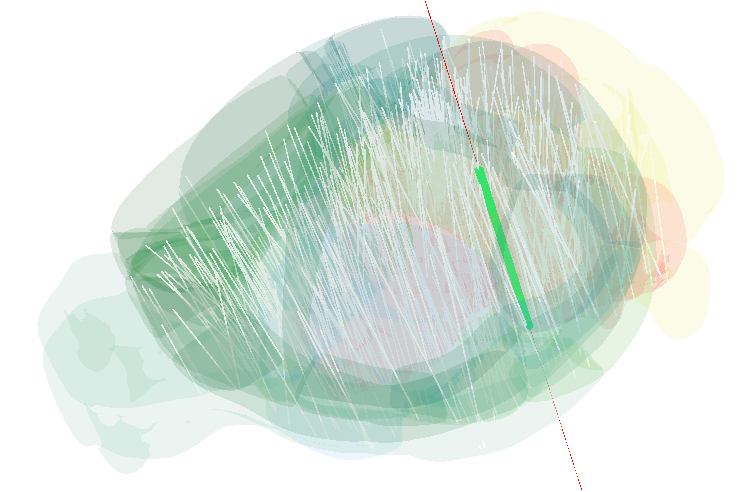|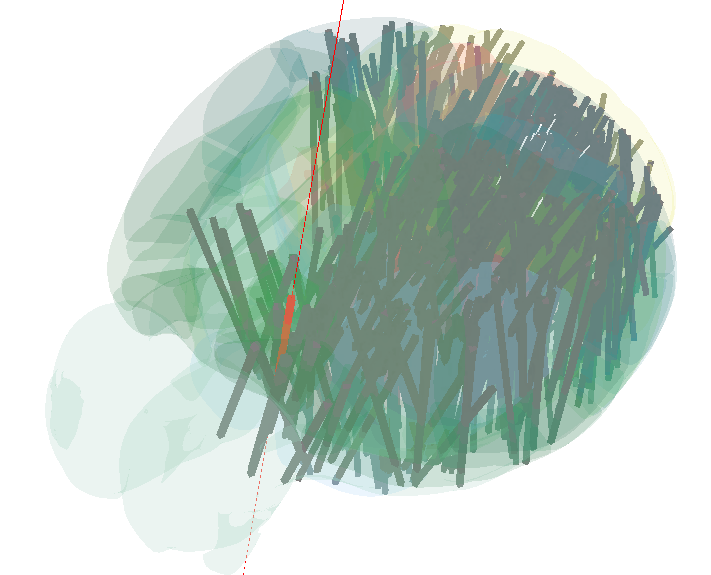|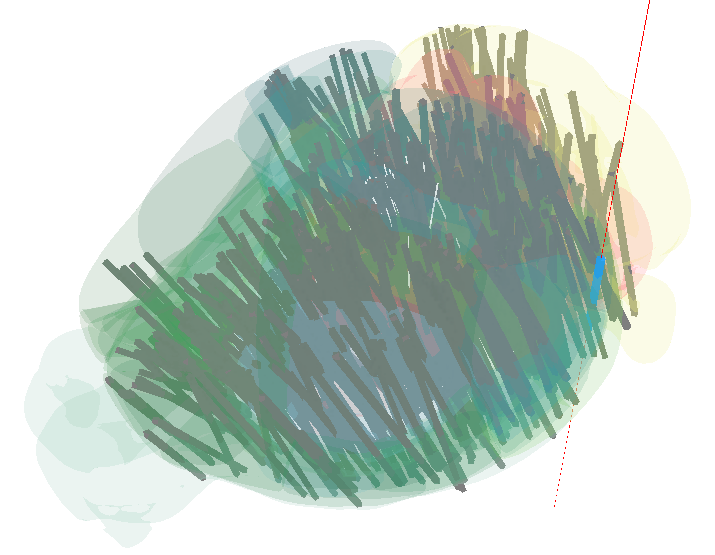|
|---|---|---|
|cde63527-7f5a-4cc3-8ac2-215d82e7da26|dd4da095-4a99-4bf3-9727-f735077dba66|8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8|

In [1]:
# IBL kernel: partially download raw AP data for multiple EID/probe datasets and build short .ap.bin files.
#
# This cell is intentionally separate from the full-download cells above. It uses HTTP Range requests
# so each dataset only downloads the first PARTIAL_DOWNLOAD_GB of the .ap.cbin file, plus the small
# .ap.ch and .ap.meta sidecars. It then streams the available prefix into a short .ap.bin that can be
# used by the Kilosort4 cell below.

from pathlib import Path, PurePosixPath
from datetime import datetime
import csv
import json
import re
import inspect
import shutil
import urllib.request

from one.api import ONE

ROOT = Path('G:/academic')
CACHE_DIR = ROOT / 'ONE'
PARTIAL_ROOT = ROOT / 'week8_partial_kilosort4_runs'
PARTIAL_ROOT.mkdir(parents=True, exist_ok=True)

one = ONE(base_url='https://openalyx.internationalbrainlab.org', cache_dir=CACHE_DIR, mode='remote')

# Edit this list. Set pid instead of eid if that is more convenient.
PARTIAL_DATASETS = [
    {'eid': 'cde63527-7f5a-4cc3-8ac2-215d82e7da26', 'pid': None, 'probe': 'probe01'},
    {'eid': 'dd4da095-4a99-4bf3-9727-f735077dba66', 'pid': None, 'probe': 'probe00'},
    {'eid': '8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8', 'pid': None, 'probe': 'probe00'},
    # {'eid': 'bb099402-4ef1-4e62-8025-7b0d6f3dcb36', 'pid': None, 'probe': 'probe00'},
]

# Keep this small for testing. Increase after the workflow is confirmed.
PARTIAL_DOWNLOAD_GB = 1.8
PARTIAL_MAX_SECONDS = 600.0
PARTIAL_CHUNK_SECONDS = 10.0
PARTIAL_OVERWRITE = False
RUN_PARTIAL_DOWNLOAD = True


def read_spikeglx_meta_text(meta_path):
    meta = {}
    for line in Path(meta_path).read_text(errors='ignore').splitlines():
        if '=' in line:
            key, value = line.split('=', 1)
            meta[key.strip()] = value.strip()
    return meta


def download_http_range(url, target, n_bytes=None, overwrite=False):
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists() and not overwrite:
        existing = target.stat().st_size
        if n_bytes is None or existing >= int(n_bytes):
            return {'path': str(target), 'status': 'skipped_existing', 'size': existing, 'requested_bytes': n_bytes, 'url': url}

    headers = {}
    if n_bytes is not None:
        headers['Range'] = f'bytes=0-{int(n_bytes) - 1}'
    req = urllib.request.Request(url, headers=headers)
    tmp = target.with_suffix(target.suffix + '.part')
    with urllib.request.urlopen(req, timeout=120) as response, tmp.open('wb') as out:
        shutil.copyfileobj(response, out, length=1024 * 1024)
    tmp.replace(target)
    size = target.stat().st_size
    status = 'complete' if n_bytes is None or size == int(n_bytes) else 'partial_or_server_ignored_range'
    return {'path': str(target), 'status': status, 'size': size, 'requested_bytes': n_bytes, 'url': url}


def write_partial_ch_for_cbin(full_ch_path, partial_cbin_path):
    """Rewrite the .ap.ch next to a partial .ap.cbin so mtscomp only sees complete chunks.

    A full .ap.ch points to chunks across the full remote .ap.cbin. If the cbin is an HTTP
    Range prefix, mtscomp will eventually seek past EOF and raise AssertionError. This keeps
    only chunks whose compressed bytes are fully present in the partial cbin.
    """
    full_ch_path = Path(full_ch_path)
    partial_cbin_path = Path(partial_cbin_path)
    active_ch_path = partial_cbin_path.with_suffix('.ch')
    backup_ch_path = active_ch_path.with_name(active_ch_path.name.replace('.ap.ch', '.full.ap.ch'))

    if active_ch_path.exists() and not backup_ch_path.exists():
        active_ch_path.replace(backup_ch_path)
    source_ch_path = backup_ch_path if backup_ch_path.exists() else full_ch_path

    ch = json.loads(source_ch_path.read_text())
    offsets = ch['chunk_offsets']
    bounds = ch['chunk_bounds']
    cbin_size = partial_cbin_path.stat().st_size

    # offsets has length n_chunks + 1. A chunk i is complete only if offsets[i + 1] <= cbin_size.
    complete_chunks = 0
    for i in range(len(offsets) - 1):
        if int(offsets[i + 1]) <= cbin_size:
            complete_chunks = i + 1
        else:
            break
    if complete_chunks <= 0:
        raise RuntimeError(f'Partial cbin is too small to contain even one complete mtscomp chunk: {partial_cbin_path}')

    partial = dict(ch)
    partial['chunk_offsets'] = offsets[:complete_chunks + 1]
    partial['chunk_bounds'] = bounds[:complete_chunks + 1]
    partial['sha1_compressed'] = None
    partial['sha1_uncompressed'] = None
    active_ch_path.write_text(json.dumps(partial, indent=2), encoding='utf-8')
    return {
        'full_ch_path': str(source_ch_path),
        'partial_ch_path': str(active_ch_path),
        'partial_cbin_size': cbin_size,
        'complete_chunks': complete_chunks,
        'partial_samples_from_ch': int(partial['chunk_bounds'][-1]),
    }


def alyx_dataset_records(eid, rel_path):
    rel_path = PurePosixPath(str(rel_path))
    return one.alyx.rest(
        'datasets', 'list',
        session=str(eid),
        name=rel_path.name,
        collection=str(rel_path.parent),
    )


def url_from_file_records(record):
    for file_record in record.get('file_records', []) or []:
        for key in ('data_url', 'download_url', 'url'):
            value = file_record.get(key)
            if value and str(value).startswith('http'):
                return value
        repo = file_record.get('data_repository') or {}
        repo_url = repo.get('data_url') or repo.get('hostname')
        rel = file_record.get('relative_path') or record.get('rel_path')
        if repo_url and rel and str(repo_url).startswith('http'):
            return str(repo_url).rstrip('/') + '/' + str(rel).lstrip('/')
    return None


def static_openalyx_url(eid, rel_path):
    session_path_raw = Path(one.eid2path(eid))
    try:
        session_path_raw = session_path_raw.relative_to(CACHE_DIR)
    except ValueError:
        pass
    parts = session_path_raw.parts
    if parts and parts[0] == 'openalyx.internationalbrainlab.org':
        parts = parts[1:]
    session_path = PurePosixPath(*parts)
    rel_path = PurePosixPath(str(rel_path))
    return 'https://openalyx.internationalbrainlab.org/' + (session_path / rel_path).as_posix()


def resolve_dataset_url(eid, rel_path):
    records = alyx_dataset_records(eid, rel_path)
    for record in records:
        url = url_from_file_records(record)
        if url:
            return url
    return static_openalyx_url(eid, rel_path)


def list_raw_ap_rows(eid, probe):
    datasets = one.list_datasets(eid, details=True, query_type='remote', keep_eid_index=True)
    rel = datasets['rel_path'].astype(str)
    rows = datasets.loc[
        rel.str.contains(rf'^raw_ephys_data/{re.escape(probe)}/', regex=True)
        & rel.str.contains(r'\.ap\.(?:cbin|meta|ch)$', regex=True),
        ['rel_path', 'file_size']
    ].copy()
    if rows.empty:
        raise RuntimeError(f'No raw AP cbin/meta/ch files found for {eid} / {probe}.')
    return rows.sort_values('rel_path')


def parse_dataset_config(config):
    eid = config.get('eid')
    probe = config.get('probe')
    pid = config.get('pid')
    if eid is None:
        if not pid:
            raise ValueError('Each PARTIAL_DATASETS entry needs eid or pid.')
        eid, probe_from_pid = one.pid2eid(pid)
        probe = probe or probe_from_pid
    if not probe:
        raise ValueError(f'Missing probe for dataset {config}')
    return str(eid), str(pid) if pid else None, str(probe)


def create_partial_rawint16_bin(reader, out_path, fs, max_seconds, overwrite=False):
    """Create a short raw int16 .ap.bin using spikeglx's native decompressor.

    Do not write reader[...] slices here: those may be scaled values and casting them to int16
    can flatten AP data to near-zero values, causing Kilosort to detect no spikes.
    """
    out_path = Path(out_path)
    n_chan = int(reader.nc)
    if out_path.exists() and not overwrite:
        samples = out_path.stat().st_size // (n_chan * 2)
        return {'status': 'skipped_existing', 'samples_written': samples, 'path': str(out_path), 'size': out_path.stat().st_size}

    max_samples = int(max_seconds * fs) if max_seconds else int(getattr(reader, 'ns', 0) or 0)
    available_samples = int(getattr(reader, 'ns', 0) or 0)
    target_samples = max(1, min(max_samples, available_samples)) if available_samples else max_samples
    out_path.parent.mkdir(parents=True, exist_ok=True)

    kwargs = {'keep_original': True, 'out': out_path, 'overwrite': True}
    signature = inspect.signature(reader.decompress_file)
    if 'first_sample' in signature.parameters:
        kwargs['first_sample'] = 0
    if 'last_sample' in signature.parameters:
        kwargs['last_sample'] = target_samples

    try:
        reader.decompress_file(**kwargs)
    except TypeError:
        # Older spikeglx versions may not expose first_sample/last_sample. Because the source
        # .cbin itself is already a prefix download, full decompression still stays partial.
        reader.decompress_file(keep_original=True, out=out_path, overwrite=True)

    samples = out_path.stat().st_size // (n_chan * 2)
    if samples <= 0:
        raise RuntimeError(f'Created partial AP bin has 0 samples: {out_path}')
    return {'status': 'created', 'samples_written': samples, 'path': str(out_path), 'size': out_path.stat().st_size}


partial_manifest_rows = []
partial_run_infos = []
partial_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')

if RUN_PARTIAL_DOWNLOAD:
    for config in PARTIAL_DATASETS:
        eid, pid, probe = parse_dataset_config(config)
        run_label = f'{eid.split("-")[0]}_{probe}_partial_{partial_stamp}'
        run_dir = PARTIAL_ROOT / run_label
        raw_dir = run_dir / 'raw_ephys_data' / probe
        raw_dir.mkdir(parents=True, exist_ok=True)
        print('\npartial dataset:', eid, probe)
        print('run_dir:', run_dir)

        rows = list_raw_ap_rows(eid, probe)
        cbin_row = rows[rows['rel_path'].astype(str).str.endswith('.ap.cbin')].iloc[0]
        sidecar_rows = rows[rows['rel_path'].astype(str).str.endswith(('.ap.ch', '.ap.meta'))]

        download_records = []
        for _, row in sidecar_rows.iterrows():
            rel_path = PurePosixPath(str(row['rel_path']))
            url = resolve_dataset_url(eid, rel_path)
            target = raw_dir / rel_path.name
            record = download_http_range(url, target, n_bytes=None, overwrite=PARTIAL_OVERWRITE)
            record.update({'eid': eid, 'pid': pid, 'probe': probe, 'rel_path': rel_path.as_posix(), 'file_kind': rel_path.suffix})
            download_records.append(record)
            partial_manifest_rows.append(record)
            print(record['status'], target, record['size'])

        cbin_rel = PurePosixPath(str(cbin_row['rel_path']))
        cbin_url = resolve_dataset_url(eid, cbin_rel)
        cbin_expected_size = int(cbin_row['file_size'])
        cbin_partial_bytes = min(cbin_expected_size, int(PARTIAL_DOWNLOAD_GB * 1e9))
        cbin_target = raw_dir / cbin_rel.name
        cbin_record = download_http_range(cbin_url, cbin_target, n_bytes=cbin_partial_bytes, overwrite=PARTIAL_OVERWRITE)
        cbin_record.update({'eid': eid, 'pid': pid, 'probe': probe, 'rel_path': cbin_rel.as_posix(), 'file_kind': '.cbin', 'full_file_size': cbin_expected_size})
        download_records.append(cbin_record)
        partial_manifest_rows.append(cbin_record)
        print(cbin_record['status'], cbin_target, cbin_record['size'], '/', cbin_expected_size)

        full_ch_path = raw_dir / cbin_rel.name.replace('.ap.cbin', '.ap.ch')
        ch_record = write_partial_ch_for_cbin(full_ch_path, cbin_target)
        ch_record.update({'eid': eid, 'pid': pid, 'probe': probe, 'rel_path': str(Path(ch_record['partial_ch_path']).relative_to(run_dir)), 'file_kind': '.partial.ap.ch'})
        partial_manifest_rows.append(ch_record)
        print('partial .ap.ch complete chunks:', ch_record['complete_chunks'], 'samples:', ch_record['partial_samples_from_ch'])

        import spikeglx
        reader = spikeglx.Reader(cbin_target)
        meta_path = cbin_target.with_suffix('.meta')
        meta = read_spikeglx_meta_text(meta_path)
        fs = float(meta.get('imSampRate') or meta.get('niSampRate') or 30000)
        partial_bin = raw_dir / cbin_target.name.replace('.ap.cbin', f'.first_{int(PARTIAL_MAX_SECONDS)}s.chunked.rawint16.ap.bin')
        bin_record = create_partial_rawint16_bin(
            reader,
            partial_bin,
            fs=fs,
            max_seconds=PARTIAL_MAX_SECONDS,
            overwrite=PARTIAL_OVERWRITE,
        )
        bin_record.update({
            'eid': eid,
            'pid': pid,
            'probe': probe,
            'rel_path': str(partial_bin.relative_to(run_dir)),
            'file_kind': '.partial.ap.bin',
            'requested_bytes': '',
            'url': '',
            'full_file_size': '',
            'partial_download_gb': PARTIAL_DOWNLOAD_GB,
            'partial_max_seconds': PARTIAL_MAX_SECONDS,
            'partial_chunk_seconds': PARTIAL_CHUNK_SECONDS,
            'fs': fs,
        })
        partial_manifest_rows.append(bin_record)
        print(bin_record['status'], partial_bin, bin_record['samples_written'], 'samples')

        run_info = {
            'eid': eid,
            'pid': pid,
            'probe': probe,
            'run_label': run_label,
            'run_dir': str(run_dir),
            'partial_ap_cbin': str(cbin_target),
            'partial_ap_ch': ch_record['partial_ch_path'],
            'full_ap_ch': ch_record['full_ch_path'],
            'partial_ap_bin': str(partial_bin),
            'partial_download_gb': PARTIAL_DOWNLOAD_GB,
            'partial_max_seconds': PARTIAL_MAX_SECONDS,
            'partial_chunk_seconds': PARTIAL_CHUNK_SECONDS,
            'partial_samples_written': bin_record['samples_written'],
            'partial_ch_record': ch_record,
            'download_records': download_records,
            'partial_bin_record': bin_record,
        }
        (run_dir / 'run_info_partial_download.json').write_text(json.dumps(run_info, indent=2), encoding='utf-8')
        partial_run_infos.append(run_info)

manifest_path = PARTIAL_ROOT / f'partial_download_manifest_{partial_stamp}.csv'
if partial_manifest_rows:
    fieldnames = sorted({key for row in partial_manifest_rows for key in row.keys()})
    with manifest_path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(partial_manifest_rows)
    print('\nsaved partial download manifest:', manifest_path)
else:
    print('No partial downloads were run. Set RUN_PARTIAL_DOWNLOAD=True.')



partial dataset: cde63527-7f5a-4cc3-8ac2-215d82e7da26 probe01
run_dir: G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836
complete G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\raw_ephys_data\probe01\_spikeglx_ephysData_g0_t0.imec1.ap.ch 105975
complete G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\raw_ephys_data\probe01\_spikeglx_ephysData_g0_t0.imec1.ap.meta 17755
complete G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\raw_ephys_data\probe01\_spikeglx_ephysData_g0_t0.imec1.ap.cbin 1800000000 / 30071167613
partial .ap.ch complete chunks: 209 samples: 6270000


E:\Anaconda\envs\ibl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\raw_ephys_data\probe01\_spikeglx_ephysData_g0_t0.imec1.ap.cbin : meta data and compressed chunks dont checkout
File duration: expected 3454.4229666666665, actual 209.0
Will attempt to fudge the meta-data information.
Decompressing: 100%|██████████| 18/18 [01:48<00:00,  6.01s/it]
INFO:mtscomp:Wrote G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\raw_ephys_data\probe01\_spikeglx_ephysData_g0_t0.imec1.first_600s.chunked.rawint16.ap.bin (4.5 GB).
Checking: 100%|██████████| 209/209 [02:31<00:00,  1.38it/s]


created G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\raw_ephys_data\probe01\_spikeglx_ephysData_g0_t0.imec1.first_600s.chunked.rawint16.ap.bin 6270000 samples

partial dataset: dd4da095-4a99-4bf3-9727-f735077dba66 probe00
run_dir: G:\academic\week8_partial_kilosort4_runs\dd4da095_probe00_partial_20260712_222836
complete G:\academic\week8_partial_kilosort4_runs\dd4da095_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec.ap.ch 77963
complete G:\academic\week8_partial_kilosort4_runs\dd4da095_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec.ap.meta 16755


File duration: expected 2560.9352, actual 214.0
Will attempt to fudge the meta-data information.


complete G:\academic\week8_partial_kilosort4_runs\dd4da095_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec.ap.cbin 1800000000 / 21278555040
partial .ap.ch complete chunks: 214 samples: 6420000


...

created G:\academic\week8_partial_kilosort4_runs\dd4da095_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec.first_600s.chunked.rawint16.ap.bin 6420000 samples

partial dataset: 8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8 probe00
run_dir: G:\academic\week8_partial_kilosort4_runs\8ca740c5_probe00_partial_20260712_222836
complete G:\academic\week8_partial_kilosort4_runs\8ca740c5_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.ch 125073
complete G:\academic\week8_partial_kilosort4_runs\8ca740c5_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.meta 17729


File duration: expected 4053.9022666666665, actual 220.0
Will attempt to fudge the meta-data information.


complete G:\academic\week8_partial_kilosort4_runs\8ca740c5_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.cbin 1800000000 / 33334777990
partial .ap.ch complete chunks: 220 samples: 6600000


Decompressing: 100%|██████████| 19/19 [01:49<00:00,  5.77s/it]
INFO:mtscomp:Wrote G:\academic\week8_partial_kilosort4_runs\8ca740c5_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.first_600s.chunked.rawint16.ap.bin (4.7 GB).
Checking: 100%|██████████| 220/220 [02:18<00:00,  1.59it/s]


created G:\academic\week8_partial_kilosort4_runs\8ca740c5_probe00_partial_20260712_222836\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.first_600s.chunked.rawint16.ap.bin 6600000 samples

saved partial download manifest: G:\academic\week8_partial_kilosort4_runs\partial_download_manifest_20260712_222836.csv


In [1]:
# Kilosort4 kernel: run Kilosort4 on each short .ap.bin created by the partial-download cell.
#
# Switch to the Kilosort4 kernel before running this cell. By default, each Kilosort run is executed
# in a separate Python subprocess. This avoids repeated low-level dispatcher/tracer initialization
# errors such as "CPU dispatcher tracer already initialized" in a long-lived Jupyter kernel.

from pathlib import Path
import csv
import json
import subprocess
import sys
import textwrap
import numpy as np

ROOT = Path('G:/academic')
PARTIAL_ROOT = ROOT / 'week8_partial_kilosort4_runs'

RUN_PARTIAL_KILOSORT4 = True
RUN_KILOSORT4_IN_SUBPROCESS = True
ALLOW_PARTIAL_KS_OVERWRITE = False

PARTIAL_RUN_DIRS = []

KS_NEAREST_CHANS = 2
KS_N_PCS = 2
SAVE_EXTRA_VARS = False
CLEAR_CACHE = True
PARTIAL_MIN_SECONDS_FOR_KS = 180.0
PARTIAL_MIN_SIGNAL_STD = 10.0


def read_spikeglx_meta(meta_path):
    meta = {}
    for line in Path(meta_path).read_text(errors='ignore').splitlines():
        if '=' in line:
            key, value = line.split('=', 1)
            meta[key.strip()] = value.strip()
    return meta


def infer_partial_kilosort_settings(ap_bin):
    ap_bin = Path(ap_bin)
    meta_candidates = [ap_bin.with_suffix('.meta'), Path(str(ap_bin).replace('.first_', '.ap.').replace('.ap.bin', '.ap.meta'))]
    meta_candidates.extend(ap_bin.parent.glob('*.ap.meta'))
    meta_path = next((p for p in meta_candidates if p.exists()), None)
    n_chan_bin = 385
    fs = 30000
    if meta_path is not None:
        meta = read_spikeglx_meta(meta_path)
        n_chan_bin = int(meta.get('nSavedChans', n_chan_bin))
        fs_text = meta.get('imSampRate') or meta.get('niSampRate')
        if fs_text is not None:
            fs = float(fs_text)
    return {
        'filename': ap_bin,
        'n_chan_bin': n_chan_bin,
        'fs': fs,
        'nearest_chans': KS_NEAREST_CHANS,
        'n_pcs': KS_N_PCS,
    }


def inspect_partial_ap_bin(ap_bin, settings):
    ap_bin = Path(ap_bin)
    n_chan = int(settings['n_chan_bin'])
    fs = float(settings['fs'])
    samples = ap_bin.stat().st_size // (n_chan * 2)
    seconds = samples / fs if fs else 0
    raw = np.memmap(ap_bin, dtype='int16', mode='r')
    sample_count = min(raw.size, n_chan * int(min(samples, fs * 5)))
    sample = np.asarray(raw[:sample_count]) if sample_count else np.asarray([], dtype='int16')
    signal_std = float(sample.std()) if sample.size else 0.0
    return {'samples': int(samples), 'seconds': float(seconds), 'signal_std': signal_std, 'n_chan_bin': n_chan, 'fs': fs}


def partial_run_info_paths():
    if PARTIAL_RUN_DIRS:
        dirs = [Path(path) for path in PARTIAL_RUN_DIRS]
    else:
        dirs = sorted(PARTIAL_ROOT.glob('*_partial_*'), key=lambda path: path.stat().st_mtime)
    return [d / 'run_info_partial_download.json' for d in dirs if (d / 'run_info_partial_download.json').exists()]


def write_kilosort_subprocess_script(script_path):
    script_template = """
from pathlib import Path
import json
import sys

from kilosort import run_kilosort

run_info_path = Path(sys.argv[1])
settings_path = Path(sys.argv[2])
results_dir = Path(sys.argv[3])
save_extra_vars = __SAVE_EXTRA_VARS__
clear_cache = __CLEAR_CACHE__

run_info = json.loads(run_info_path.read_text(encoding='utf-8'))
settings_raw = json.loads(settings_path.read_text(encoding='utf-8'))
settings = dict(settings_raw)
settings['filename'] = Path(settings['filename'])

results_dir.mkdir(parents=True, exist_ok=True)
run_kilosort(
    settings=settings,
    probe_name='NeuroPix1_default.mat',
    results_dir=results_dir,
    data_dtype='int16',
    save_extra_vars=save_extra_vars,
    clear_cache=clear_cache,
    verbose_console=True,
)
run_info['partial_kilosort_results_dir'] = str(results_dir)
run_info['partial_kilosort_settings'] = {k: str(v) for k, v in settings.items()}
run_info['partial_kilosort_status'] = 'complete'
(run_info_path.parent / 'run_info_partial_kilosort4.json').write_text(json.dumps(run_info, indent=2), encoding='utf-8')
"""
    script = script_template.replace('__SAVE_EXTRA_VARS__', repr(SAVE_EXTRA_VARS)).replace('__CLEAR_CACHE__', repr(CLEAR_CACHE))
    script_path.write_text(textwrap.dedent(script), encoding='utf-8')


ks_manifest_rows = []
info_paths = partial_run_info_paths()
if not info_paths:
    raise FileNotFoundError('No partial run_info_partial_download.json files found. Run the partial-download cell first.')

if RUN_PARTIAL_KILOSORT4 and not RUN_KILOSORT4_IN_SUBPROCESS:
    from kilosort import run_kilosort

for info_path in info_paths:
    run_info = json.loads(info_path.read_text(encoding='utf-8'))
    run_dir = Path(run_info['run_dir'])
    ap_bin = Path(run_info['partial_ap_bin'])
    results_dir = run_dir / 'kilosort4_partial'

    if not ap_bin.exists():
        raise FileNotFoundError(f'Partial AP bin not found: {ap_bin}')

    settings = infer_partial_kilosort_settings(ap_bin)
    bin_quality = inspect_partial_ap_bin(ap_bin, settings)
    print('\npartial Kilosort dataset:', run_info['eid'], run_info['probe'])
    print('partial bin quality:', bin_quality)

    base_manifest_row = {
        'eid': run_info['eid'],
        'pid': run_info.get('pid'),
        'probe': run_info['probe'],
        'run_dir': str(run_dir),
        'partial_ap_bin': str(ap_bin),
        'partial_ap_bin_bytes': ap_bin.stat().st_size,
        'partial_samples_written': run_info.get('partial_samples_written'),
        'partial_seconds': bin_quality['seconds'],
        'signal_std': bin_quality['signal_std'],
        'kilosort_results_dir': str(results_dir),
    }

    if bin_quality['seconds'] < PARTIAL_MIN_SECONDS_FOR_KS or bin_quality['signal_std'] < PARTIAL_MIN_SIGNAL_STD:
        status = 'skipped_short_or_flat_input'
        print('skipping Kilosort:', status, ap_bin)
        ks_manifest_rows.append({**base_manifest_row, 'status': status})
        continue

    if results_dir.exists() and any(results_dir.iterdir()) and not ALLOW_PARTIAL_KS_OVERWRITE:
        print('skipping existing Kilosort output:', results_dir)
        ks_manifest_rows.append({**base_manifest_row, 'status': 'skipped_existing'})
        continue

    status = 'not_run'
    error_message = ''
    if RUN_PARTIAL_KILOSORT4:
        print('settings:', settings)
        print('results_dir:', results_dir)
        if RUN_KILOSORT4_IN_SUBPROCESS:
            settings_path = run_dir / 'partial_kilosort_settings.json'
            script_path = run_dir / 'run_partial_kilosort4_subprocess.py'
            log_path = run_dir / 'partial_kilosort4_subprocess.log'
            settings_for_json = {k: str(v) if isinstance(v, Path) else v for k, v in settings.items()}
            settings_path.write_text(json.dumps(settings_for_json, indent=2), encoding='utf-8')
            write_kilosort_subprocess_script(script_path)
            print('running subprocess:', sys.executable, script_path)
            proc = subprocess.run(
                [sys.executable, str(script_path), str(info_path), str(settings_path), str(results_dir)],
                text=True,
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
            )
            log_path.write_text(proc.stdout or '', encoding='utf-8')
            print(proc.stdout[-4000:] if proc.stdout else '')
            if proc.returncode == 0:
                status = 'complete'
            else:
                status = 'failed_subprocess'
                error_message = f'returncode={proc.returncode}; see {log_path}'
        else:
            try:
                run_kilosort(
                    settings=settings,
                    probe_name='NeuroPix1_default.mat',
                    results_dir=results_dir,
                    data_dtype='int16',
                    save_extra_vars=SAVE_EXTRA_VARS,
                    clear_cache=CLEAR_CACHE,
                    verbose_console=True,
                )
                status = 'complete'
            except ValueError as exc:
                if '0 sample' in str(exc) or 'minimum of 1' in str(exc):
                    status = 'failed_no_detected_spikes_for_svd'
                    error_message = str(exc)
                    print('Kilosort failed because no events reached the SVD step. Increase PARTIAL_DOWNLOAD_GB/PARTIAL_MAX_SECONDS or choose a later/richer segment.')
                    print(exc)
                else:
                    raise
    else:
        print('RUN_PARTIAL_KILOSORT4 is False; dry run only.')

    run_info['partial_kilosort_results_dir'] = str(results_dir)
    run_info['partial_kilosort_settings'] = {k: str(v) for k, v in settings.items()}
    run_info['partial_kilosort_status'] = status
    if error_message:
        run_info['partial_kilosort_error'] = error_message
    (run_dir / 'run_info_partial_kilosort4.json').write_text(json.dumps(run_info, indent=2), encoding='utf-8')

    ks_manifest_rows.append({**base_manifest_row, 'status': status, 'error': error_message})

manifest_path = PARTIAL_ROOT / 'partial_kilosort4_manifest.csv'
if ks_manifest_rows:
    fieldnames = sorted({key for row in ks_manifest_rows for key in row.keys()})
    with manifest_path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(ks_manifest_rows)
    print('\nsaved partial Kilosort manifest:', manifest_path)



partial Kilosort dataset: cde63527-7f5a-4cc3-8ac2-215d82e7da26 probe01
partial bin quality: {'samples': 6270000, 'seconds': 209.0, 'signal_std': 18.453305413954954, 'n_chan_bin': 385, 'fs': 30000.0}
settings: {'filename': WindowsPath('G:/academic/week8_partial_kilosort4_runs/cde63527_probe01_partial_20260712_222836/raw_ephys_data/probe01/_spikeglx_ephysData_g0_t0.imec1.first_600s.chunked.rawint16.ap.bin'), 'n_chan_bin': 385, 'fs': 30000.0, 'nearest_chans': 2, 'n_pcs': 2}
results_dir: G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\kilosort4_partial
running subprocess: E:\Anaconda\envs\kilosort\python.exe G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\run_partial_kilosort4_subprocess.py
rt INFO     Max alloc:     0.27 %     |      0.01   /     4.00 GB
2026-07-12 23:52:09,410 kilosort.run_kilosort INFO     ********************************************************
2026-07-12 23:52:09,411 kilosort.run_kilosort DEBUG    
2

## Partial-data DCT keep-ratio Kilosort pipeline

This section replaces the random spike-subsampling proxy with a real partial-data DCT keep-ratio workflow:

1. Start from each successful partial raw AP bin.
2. Run Kilosort preprocessing once and save `temp_wh.dat`.
3. Apply windowed DCT compression/IDCT reconstruction to the preprocessed copy for each keep ratio.
4. Run Kilosort on each DCT-reconstructed partial input.

Outputs are written under `G:/academic/week8_partial_dct_kilosort_runs/`.


In [1]:
# Kilosort4 kernel: build DCT-compressed partial inputs and run Kilosort for each keep ratio.
# This is partial-only; it does not touch the full recordings.
from pathlib import Path
import csv
import json
import subprocess
import sys
import textwrap

import numpy as np
from scipy.fftpack import dct, idct

ROOT = Path('G:/academic')
PARTIAL_ROOT = ROOT / 'week8_partial_kilosort4_runs'
DCT_ROOT = ROOT / 'week8_partial_dct_kilosort_runs'
DCT_ROOT.mkdir(parents=True, exist_ok=True)

DCT_KEEP_RATIOS = [0.10, 0.20, 0.30, 0.50, 0.70, 1.00]
DCT_WINDOW_SAMPLES = 600
RUN_DCT_PIPELINE = True
ALLOW_DCT_OVERWRITE = False

KS_NEAREST_CHANS = 2
KS_N_PCS = 2
SAVE_EXTRA_VARS = False
CLEAR_CACHE = True

# Leave empty to process all successful partial runs, or list specific run dirs.
PARTIAL_RUN_DIRS_FOR_DCT = []


def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


def read_spikeglx_meta(meta_path):
    meta = {}
    for line in Path(meta_path).read_text(errors='ignore').splitlines():
        if '=' in line:
            key, value = line.split('=', 1)
            meta[key.strip()] = value.strip()
    return meta


def infer_n_chan_fs_from_partial_info(info):
    ap_bin = Path(info['partial_ap_bin'])
    meta_candidates = list(ap_bin.parent.glob('*.ap.meta'))
    n_chan = 385
    fs = 30000.0
    if meta_candidates:
        meta = read_spikeglx_meta(meta_candidates[0])
        n_chan = int(meta.get('nSavedChans', n_chan))
        fs = float(meta.get('imSampRate') or meta.get('niSampRate') or fs)
    return n_chan, fs


def successful_partial_infos():
    if PARTIAL_RUN_DIRS_FOR_DCT:
        dirs = [Path(p) for p in PARTIAL_RUN_DIRS_FOR_DCT]
    else:
        dirs = sorted(PARTIAL_ROOT.glob('*_partial_*'), key=lambda p: p.stat().st_mtime)
    infos = []
    for d in dirs:
        info_path = d / 'run_info_partial_kilosort4.json'
        if not info_path.exists():
            continue
        info = read_json(info_path)
        if info.get('partial_kilosort_status') == 'complete' and Path(info.get('partial_ap_bin', '')).exists():
            infos.append(info)
    return infos


def script_run_kilosort(script_path):
    script = """
from pathlib import Path
import json
import sys
from kilosort import run_kilosort

settings_path = Path(sys.argv[1])
results_dir = Path(sys.argv[2])
settings_raw = json.loads(settings_path.read_text(encoding='utf-8'))

# Keep subprocess-control flags out of the Kilosort settings dict; Kilosort
# validates settings keys and rejects unknown names such as _do_CAR.
do_CAR = bool(settings_raw.pop('_do_CAR', True))
save_extra_vars = bool(settings_raw.pop('_save_extra_vars', False))
clear_cache = bool(settings_raw.pop('_clear_cache', True))
save_preprocessed_copy = bool(settings_raw.pop('_save_preprocessed_copy', False))
filename = Path(settings_raw.pop('filename'))

run_kilosort(
    settings=settings_raw,
    filename=filename,
    probe_name='NeuroPix1_default.mat',
    results_dir=results_dir,
    data_dtype='int16',
    do_CAR=do_CAR,
    save_extra_vars=save_extra_vars,
    clear_cache=clear_cache,
    save_preprocessed_copy=save_preprocessed_copy,
    verbose_console=True,
)
"""
    script_path.write_text(textwrap.dedent(script), encoding='utf-8')


def run_kilosort_subprocess(settings, results_dir, log_path, save_preprocessed_copy=False, do_CAR=True):
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)
    settings = dict(settings)
    settings['_save_preprocessed_copy'] = bool(save_preprocessed_copy)
    settings['_do_CAR'] = bool(do_CAR)
    settings['_save_extra_vars'] = bool(SAVE_EXTRA_VARS)
    settings['_clear_cache'] = bool(CLEAR_CACHE)
    settings_path = results_dir / 'settings_for_subprocess.json'
    script_path = results_dir / 'run_kilosort_subprocess.py'
    settings_path.write_text(json.dumps({k: str(v) if isinstance(v, Path) else v for k, v in settings.items()}, indent=2), encoding='utf-8')
    script_run_kilosort(script_path)
    proc = subprocess.run([sys.executable, str(script_path), str(settings_path), str(results_dir)], text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    Path(log_path).write_text(proc.stdout or '', encoding='utf-8')
    if proc.returncode != 0:
        raise RuntimeError(f'Kilosort subprocess failed with returncode={proc.returncode}; see {log_path}')
    return results_dir


def ensure_preprocessed_copy(info):
    n_chan, fs = infer_n_chan_fs_from_partial_info(info)
    run_label = Path(info['run_dir']).name
    dct_run_dir = DCT_ROOT / run_label
    preproc_dir = dct_run_dir / 'baseline_preprocessed'
    temp_wh = preproc_dir / 'temp_wh.dat'
    settings = {
        'filename': Path(info['partial_ap_bin']),
        'n_chan_bin': n_chan,
        'fs': fs,
        'nearest_chans': KS_NEAREST_CHANS,
        'n_pcs': KS_N_PCS,
    }
    if temp_wh.exists() and temp_wh.stat().st_size > 0 and not ALLOW_DCT_OVERWRITE:
        print('using cached preprocessed copy:', temp_wh)
    else:
        if not RUN_DCT_PIPELINE:
            print('dry run: would build preprocessed copy:', temp_wh)
        else:
            print('building preprocessed copy via Kilosort:', temp_wh)
            run_kilosort_subprocess(settings, preproc_dir, preproc_dir / 'preprocess_subprocess.log', save_preprocessed_copy=True, do_CAR=True)
            if not temp_wh.exists():
                raise FileNotFoundError(f'Expected Kilosort save_preprocessed_copy output missing: {temp_wh}')
    return dct_run_dir, temp_wh, n_chan, fs


def kilosort_result_exists(ks_dir):
    ks_dir = Path(ks_dir)
    required = [ks_dir / 'spike_times.npy', ks_dir / 'spike_clusters.npy']
    return all(path.exists() and path.stat().st_size > 0 for path in required)


def dct_reconstruct_preprocessed_int16(src_bin, out_bin, n_chan, keep_ratio, window_samples):
    src_bin = Path(src_bin)
    out_bin = Path(out_bin)
    n_samples = src_bin.stat().st_size // (int(n_chan) * np.dtype(np.int16).itemsize)
    src = np.memmap(src_bin, dtype=np.int16, mode='r', shape=(n_samples, int(n_chan)))
    out = np.memmap(out_bin, dtype=np.int16, mode='w+', shape=(n_samples, int(n_chan)))
    n_windows = int(np.ceil(n_samples / window_samples))
    n_keep = max(1, int(round(window_samples * keep_ratio)))
    work = np.zeros(window_samples, dtype=np.float32)
    coeff = np.zeros(window_samples, dtype=np.float32)
    for ch in range(int(n_chan)):
        for win in range(n_windows):
            start = win * window_samples
            stop = min(n_samples, start + window_samples)
            valid = stop - start
            work.fill(0)
            work[:valid] = np.asarray(src[start:stop, ch], dtype=np.float32)
            c = dct(work, norm='ortho')
            coeff.fill(0)
            coeff[:n_keep] = c[:n_keep]
            rec = idct(coeff, norm='ortho')[:valid]
            out[start:stop, ch] = np.clip(np.rint(rec), -32768, 32767).astype(np.int16)
    out.flush()
    del src, out
    return {'n_samples': int(n_samples), 'n_chan': int(n_chan), 'n_windows': int(n_windows), 'n_keep': int(n_keep)}


manifest_rows = []
for info in successful_partial_infos():
    run_label = Path(info['run_dir']).name
    dct_run_dir, temp_wh, n_chan, fs = ensure_preprocessed_copy(info)
    for ratio in DCT_KEEP_RATIOS:
        ratio_label = f'ratio_{ratio:.2f}'
        ratio_dir = dct_run_dir / ratio_label
        dct_bin = ratio_dir / f'{run_label}_{ratio_label}_dctwin_{DCT_WINDOW_SAMPLES}samp_preprocessed_int16.bin'
        ks_dir = ratio_dir / 'kilosort4_dct'
        status = 'not_run'
        error = ''
        try:
            ratio_dir.mkdir(parents=True, exist_ok=True)
            existing_ks = kilosort_result_exists(ks_dir)
            if existing_ks and not ALLOW_DCT_OVERWRITE:
                status = 'skipped_existing'
                dct_meta = {
                    'n_samples': dct_bin.stat().st_size // (n_chan * 2) if dct_bin.exists() else None,
                    'n_chan': n_chan,
                    'n_windows': None,
                    'n_keep': int(round(DCT_WINDOW_SAMPLES * ratio)),
                }
                print('using cached DCT Kilosort; skipping DCT rebuild and rerun:', ks_dir)
            else:
                if dct_bin.exists() and dct_bin.stat().st_size > 0 and not ALLOW_DCT_OVERWRITE:
                    dct_meta = {'n_samples': dct_bin.stat().st_size // (n_chan * 2), 'n_chan': n_chan, 'n_windows': None, 'n_keep': int(round(DCT_WINDOW_SAMPLES * ratio))}
                    print('using cached DCT bin:', dct_bin)
                else:
                    if RUN_DCT_PIPELINE:
                        print('building DCT reconstructed bin:', dct_bin)
                        dct_meta = dct_reconstruct_preprocessed_int16(temp_wh, dct_bin, n_chan, ratio, DCT_WINDOW_SAMPLES)
                    else:
                        dct_meta = {'n_samples': None, 'n_chan': n_chan, 'n_windows': None, 'n_keep': int(round(DCT_WINDOW_SAMPLES * ratio))}
                if RUN_DCT_PIPELINE:
                    settings = {'filename': dct_bin, 'n_chan_bin': n_chan, 'fs': fs, 'nearest_chans': KS_NEAREST_CHANS, 'n_pcs': KS_N_PCS}
                    # Data are already Kilosort-preprocessed; skip CAR. Kilosort will still compute its internal filters/whitening.
                    run_kilosort_subprocess(settings, ks_dir, ratio_dir / 'dct_kilosort_subprocess.log', save_preprocessed_copy=False, do_CAR=False)
                    status = 'complete'
                else:
                    status = 'dry_run'
        except Exception as exc:
            status = 'failed'
            error = str(exc)
            print('DCT ratio failed:', run_label, ratio, error)
        row = {
            'run_label': run_label,
            'eid': info.get('eid'),
            'probe': info.get('probe'),
            'baseline_partial_run_dir': info.get('run_dir'),
            'baseline_partial_ks_dir': info.get('partial_kilosort_results_dir'),
            'preprocessed_copy': str(temp_wh),
            'ratio': ratio,
            'dct_window_samples': DCT_WINDOW_SAMPLES,
            'dct_bin': str(dct_bin),
            'dct_kilosort_results_dir': str(ks_dir),
            'n_chan': n_chan,
            'fs': fs,
            'n_samples': dct_meta.get('n_samples'),
            'n_keep': dct_meta.get('n_keep'),
            'status': status,
            'error': error,
        }
        (ratio_dir / 'run_info_partial_dct_kilosort4.json').write_text(json.dumps(row, indent=2), encoding='utf-8')
        manifest_rows.append(row)

manifest_path = DCT_ROOT / 'partial_dct_kilosort_manifest.csv'
if manifest_rows:
    with manifest_path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=sorted({k for row in manifest_rows for k in row.keys()}))
        writer.writeheader()
        writer.writerows(manifest_rows)
    print('saved:', manifest_path)
else:
    print('No successful partial baseline runs found. Run the partial Kilosort cell first.')


using cached preprocessed copy: G:\academic\week8_partial_dct_kilosort_runs\cde63527_probe01_partial_20260712_222836\baseline_preprocessed\temp_wh.dat
using cached DCT bin: G:\academic\week8_partial_dct_kilosort_runs\cde63527_probe01_partial_20260712_222836\ratio_0.10\cde63527_probe01_partial_20260712_222836_ratio_0.10_dctwin_600samp_preprocessed_int16.bin
building DCT reconstructed bin: G:\academic\week8_partial_dct_kilosort_runs\cde63527_probe01_partial_20260712_222836\ratio_0.20\cde63527_probe01_partial_20260712_222836_ratio_0.20_dctwin_600samp_preprocessed_int16.bin
building DCT reconstructed bin: G:\academic\week8_partial_dct_kilosort_runs\cde63527_probe01_partial_20260712_222836\ratio_0.30\cde63527_probe01_partial_20260712_222836_ratio_0.30_dctwin_600samp_preprocessed_int16.bin
building DCT reconstructed bin: G:\academic\week8_partial_dct_kilosort_runs\cde63527_probe01_partial_20260712_222836\ratio_0.50\cde63527_probe01_partial_20260712_222836_ratio_0.50_dctwin_600samp_preprocess

## Partial DCT keep-ratio sensitivity analysis

This section evaluates the DCT-ratio Kilosort outputs against the corresponding partial baseline Kilosort output. Cluster IDs from independent Kilosort runs are not assumed to match, so each baseline unit is matched to the DCT unit with the best binned-count agreement, with probe-depth proximity used as a preference when available.


saved DCT sensitivity CSV files to: G:\academic\week8_population_sensitivity


,run_label,eid,probe,ratio,dct_window_samples,n_baseline_units,n_dct_units,mean_bin_accuracy,median_bin_accuracy,p10_bin_accuracy,mean_neuron_accuracy,median_neuron_accuracy,p10_neuron_accuracy,p90_neuron_accuracy,all_neuron_min_accuracy
0,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.1,600,483,767,0.833587,0.864338,0.664937,0.461340,0.540299,0.119729,0.693394,0.0
1,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.2,600,483,765,0.912521,0.930921,0.818642,0.512047,0.589684,0.155768,0.741449,0.0
2,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.3,600,483,706,0.960394,0.972531,0.933233,0.553619,0.610451,0.247675,0.774301,0.0
3,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.5,600,483,559,0.974966,0.979523,0.948632,0.623424,0.676310,0.296516,0.860621,0.0
4,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.7,600,483,514,0.983876,0.984779,0.970402,0.658531,0.710073,0.363999,0.873493,0.0
5,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,1.0,600,483,467,0.951813,0.950835,0.925167,0.692363,0.743236,0.371379,0.904326,0.0
6,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.1,600,233,247,0.144560,0.000000,0.000000,0.185780,0.090449,0.000000,0.562100,0.0
7,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.2,600,233,761,0.916512,0.926067,0.850574,0.408924,0.414039,0.071540,0.783229,0.0
8,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.3,600,233,646,0.966318,0.970739,0.934181,0.515545,0.537406,0.153989,0.877559,0.0
9,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.5,600,233,321,0.968917,0.973702,0.940571,0.570749,0.594595,0.189721,0.906677,0.0


,run_label,baseline_cluster_id,target_accuracy,target_error,required_keep_ratio,feasible,constraint_mode
1076,8ca740c5_probe00_partial_20260712_222836,NaN,0.50,0.50,0.1,True,mean_bin
1077,8ca740c5_probe00_partial_20260712_222836,NaN,0.50,0.50,NaN,False,all_neuron
1078,cde63527_probe01_partial_20260712_222836,NaN,0.50,0.50,0.2,True,mean_bin
1079,cde63527_probe01_partial_20260712_222836,NaN,0.50,0.50,NaN,False,all_neuron
1080,dd4da095_probe00_partial_20260712_222836,NaN,0.50,0.50,0.1,True,mean_bin
1081,dd4da095_probe00_partial_20260712_222836,NaN,0.50,0.50,NaN,False,all_neuron
2158,8ca740c5_probe00_partial_20260712_222836,NaN,0.70,0.30,0.1,True,mean_bin
2159,8ca740c5_probe00_partial_20260712_222836,NaN,0.70,0.30,NaN,False,all_neuron
2160,cde63527_probe01_partial_20260712_222836,NaN,0.70,0.30,0.2,True,mean_bin
2161,cde63527_probe01_partial_20260712_222836,NaN,0.70,0.30,NaN,False,all_neuron


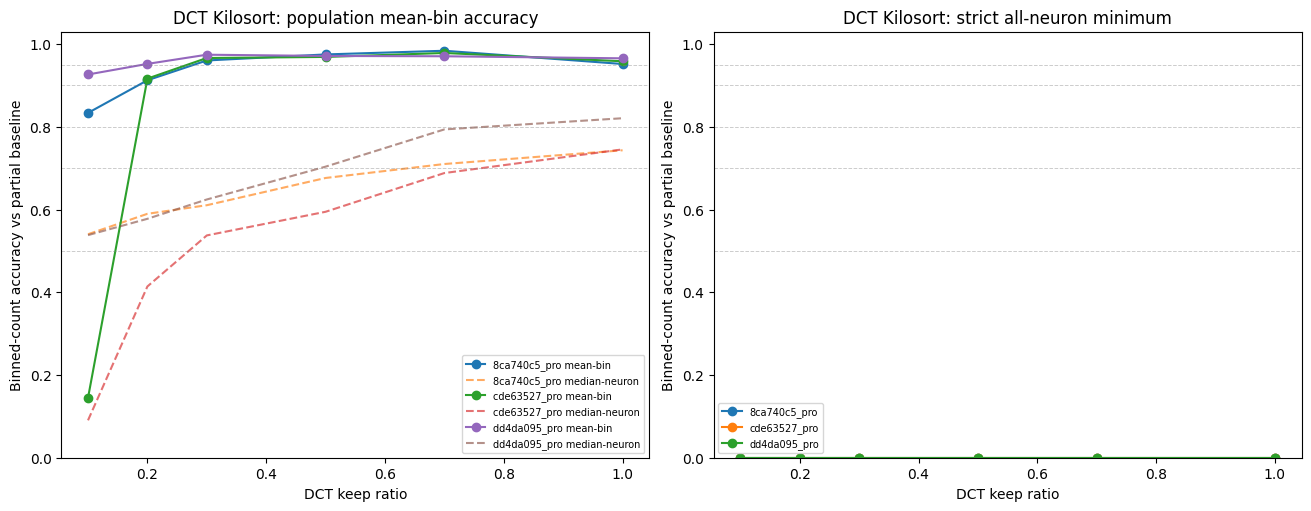

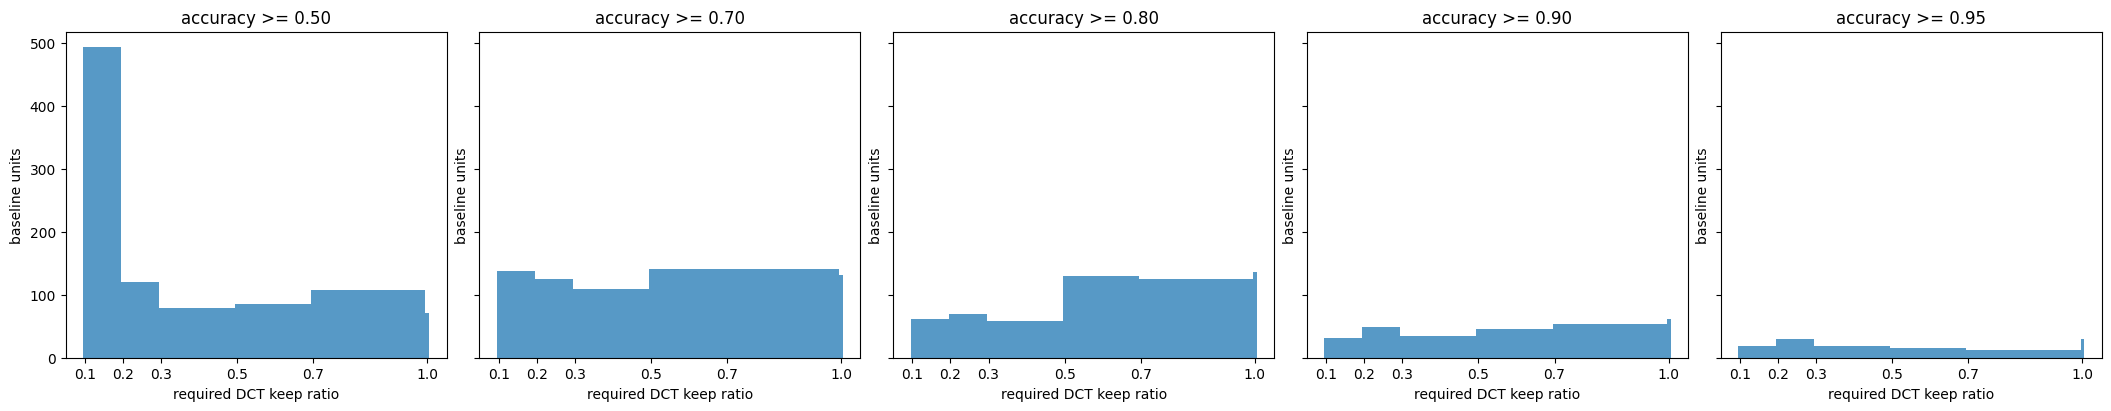

saved figures:
G:\academic\week8_population_sensitivity\week8_partial_dct_accuracy_curves.png
G:\academic\week8_population_sensitivity\week8_partial_dct_keep_ratio_distribution.png


In [2]:
# Analyze true DCT keep-ratio Kilosort outputs for partial data only.
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('G:/academic')
DCT_ROOT = ROOT / 'week8_partial_dct_kilosort_runs'
OUT_DIR = ROOT / 'week8_population_sensitivity'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DCT_ANALYSIS_BIN_SIZE_SAMPLES = 30000
DCT_MIN_SPIKES_PER_UNIT = 20
DCT_DEPTH_PREFERENCE_UM = 150.0
DCT_TARGET_ACCURACIES = [0.50, 0.70, 0.80, 0.90, 0.95]


def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


def load_units_matrix(ks_dir, bin_size_samples, min_spikes):
    ks_dir = Path(ks_dir)
    st = np.load(ks_dir / 'spike_times.npy').astype(np.int64).ravel()
    clu = np.load(ks_dir / 'spike_clusters.npy').astype(np.int64).ravel()
    depth = None
    pos_path = ks_dir / 'spike_positions.npy'
    if pos_path.exists():
        pos = np.load(pos_path)
        if pos.ndim == 2 and pos.shape[1] >= 2:
            depth = pos[:, 1]
    if st.size == 0:
        return [], np.zeros((0, 1), dtype=np.int32)
    n_bins = max(1, int(math.ceil((int(st.max()) + 1) / bin_size_samples)))
    units = []
    counts = []
    order = np.argsort(clu, kind='mergesort')
    sorted_clu = clu[order]
    bounds = np.flatnonzero(np.r_[True, sorted_clu[1:] != sorted_clu[:-1], True])
    for a, b in zip(bounds[:-1], bounds[1:]):
        idx = order[a:b]
        if idx.size < min_spikes:
            continue
        cid = int(sorted_clu[a])
        times = st[idx]
        c = np.bincount((times // bin_size_samples).astype(np.int64), minlength=n_bins).astype(np.int32)
        d = float(np.nanmedian(depth[idx])) if depth is not None else np.nan
        units.append({'cluster_id': cid, 'n_spikes': int(idx.size), 'median_depth_um': d})
        counts.append(c)
    if not counts:
        return [], np.zeros((0, n_bins), dtype=np.int32)
    return units, np.vstack(counts)


def pad_counts(a, b):
    n = max(a.shape[1], b.shape[1])
    if a.shape[1] < n:
        a = np.pad(a, ((0, 0), (0, n - a.shape[1])))
    if b.shape[1] < n:
        b = np.pad(b, ((0, 0), (0, n - b.shape[1])))
    return a, b


def binned_count_accuracy(ref_counts, test_counts):
    denom = ref_counts.sum(axis=1)
    diff = np.abs(test_counts[None, :, :] - ref_counts[:, None, :]).sum(axis=2)
    score = np.maximum(denom[:, None] - diff, 0) / np.maximum(denom[:, None], 1)
    return score


def best_match_units(ref_units, ref_counts, test_units, test_counts):
    ref_counts, test_counts = pad_counts(ref_counts, test_counts)
    if len(ref_units) == 0 or len(test_units) == 0:
        return pd.DataFrame()
    score = binned_count_accuracy(ref_counts, test_counts)
    ref_depth = np.array([u['median_depth_um'] for u in ref_units], dtype=float)
    test_depth = np.array([u['median_depth_um'] for u in test_units], dtype=float)
    if np.isfinite(ref_depth).any() and np.isfinite(test_depth).any():
        depth_diff = np.abs(ref_depth[:, None] - test_depth[None, :])
        preferred = depth_diff <= DCT_DEPTH_PREFERENCE_UM
        # Prefer nearby-depth matches without forbidding fallback for missing/poor depth data.
        score = np.where(preferred | ~np.isfinite(depth_diff), score, score * 0.75)
    best = np.argmax(score, axis=1)
    rows = []
    for i, j in enumerate(best):
        rows.append({
            'baseline_unit_index': int(i),
            'dct_unit_index': int(j),
            'baseline_cluster_id': ref_units[i]['cluster_id'],
            'dct_cluster_id': test_units[j]['cluster_id'],
            'baseline_spikes': ref_units[i]['n_spikes'],
            'dct_spikes': test_units[j]['n_spikes'],
            'baseline_depth_um': ref_units[i]['median_depth_um'],
            'dct_depth_um': test_units[j]['median_depth_um'],
            'binned_count_accuracy': float(score[i, j]),
        })
    return pd.DataFrame(rows)


def population_bin_accuracy_from_matches(ref_counts, test_counts, match_df):
    ref_counts, test_counts = pad_counts(ref_counts, test_counts)
    if match_df.empty:
        return np.array([], dtype=float)
    ref_idx = match_df['baseline_unit_index'].astype(int).to_numpy()
    test_idx = match_df['dct_unit_index'].astype(int).to_numpy()
    ref_pop = ref_counts[ref_idx, :].sum(axis=0).astype(float)
    test_pop = test_counts[test_idx, :].sum(axis=0).astype(float)
    active = ref_pop > 0
    if not active.any():
        return np.array([], dtype=float)
    diff = np.abs(test_pop[active] - ref_pop[active])
    return np.maximum(ref_pop[active] - diff, 0) / ref_pop[active]


rows = []
summary_rows = []
for info_path in sorted(DCT_ROOT.glob('*_partial_*/ratio_*/run_info_partial_dct_kilosort4.json')):
    info = read_json(info_path)
    if info.get('status') not in {'complete', 'skipped_existing'}:
        continue
    base_dir = Path(info['baseline_partial_ks_dir'])
    dct_dir = Path(info['dct_kilosort_results_dir'])
    if not (base_dir / 'spike_times.npy').exists() or not (dct_dir / 'spike_times.npy').exists():
        continue
    base_units, base_counts = load_units_matrix(base_dir, DCT_ANALYSIS_BIN_SIZE_SAMPLES, DCT_MIN_SPIKES_PER_UNIT)
    dct_units, dct_counts = load_units_matrix(dct_dir, DCT_ANALYSIS_BIN_SIZE_SAMPLES, DCT_MIN_SPIKES_PER_UNIT)
    match_df = best_match_units(base_units, base_counts, dct_units, dct_counts)
    if match_df.empty:
        continue
    match_df['run_label'] = info['run_label']
    match_df['eid'] = info.get('eid')
    match_df['probe'] = info.get('probe')
    match_df['ratio'] = float(info['ratio'])
    match_df['dct_window_samples'] = int(info['dct_window_samples'])
    rows.append(match_df)
    acc = match_df['binned_count_accuracy']
    pop_bin_acc = population_bin_accuracy_from_matches(base_counts, dct_counts, match_df)
    summary_rows.append({
        'run_label': info['run_label'],
        'eid': info.get('eid'),
        'probe': info.get('probe'),
        'ratio': float(info['ratio']),
        'dct_window_samples': int(info['dct_window_samples']),
        'n_baseline_units': len(base_units),
        'n_dct_units': len(dct_units),
        'mean_bin_accuracy': float(pop_bin_acc.mean()) if pop_bin_acc.size else np.nan,
        'median_bin_accuracy': float(np.median(pop_bin_acc)) if pop_bin_acc.size else np.nan,
        'p10_bin_accuracy': float(np.quantile(pop_bin_acc, 0.10)) if pop_bin_acc.size else np.nan,
        'mean_neuron_accuracy': float(acc.mean()),
        'median_neuron_accuracy': float(acc.median()),
        'p10_neuron_accuracy': float(acc.quantile(0.10)),
        'p90_neuron_accuracy': float(acc.quantile(0.90)),
        'all_neuron_min_accuracy': float(acc.min()),
    })

if not rows:
    raise RuntimeError('No DCT Kilosort outputs found. Run the partial DCT keep-ratio Kilosort pipeline cell first.')

dct_unit_accuracy = pd.concat(rows, ignore_index=True)
dct_run_accuracy = pd.DataFrame(summary_rows).sort_values(['run_label', 'ratio'])
required_rows = []
for target in DCT_TARGET_ACCURACIES:
    for (run_label, cluster_id), grp in dct_unit_accuracy.groupby(['run_label', 'baseline_cluster_id']):
        grp = grp.sort_values('ratio')
        ok = grp[grp['binned_count_accuracy'] >= target]
        required_rows.append({
            'run_label': run_label,
            'baseline_cluster_id': cluster_id,
            'target_accuracy': target,
            'target_error': 1 - target,
            'required_keep_ratio': float(ok.iloc[0]['ratio']) if not ok.empty else np.nan,
            'feasible': bool(not ok.empty),
        })
    for run_label, grp in dct_run_accuracy.groupby('run_label'):
        grp = grp.sort_values('ratio')
        for mode, col in [('mean_bin', 'mean_bin_accuracy'), ('all_neuron', 'all_neuron_min_accuracy')]:
            ok = grp[grp[col] >= target]
            required_rows.append({
                'run_label': run_label,
                'constraint_mode': mode,
                'target_accuracy': target,
                'target_error': 1 - target,
                'required_keep_ratio': float(ok.iloc[0]['ratio']) if not ok.empty else np.nan,
                'feasible': bool(not ok.empty),
            })

dct_required = pd.DataFrame(required_rows)
dct_unit_accuracy.to_csv(OUT_DIR / 'week8_partial_dct_unit_accuracy_by_ratio.csv', index=False)
dct_run_accuracy.to_csv(OUT_DIR / 'week8_partial_dct_run_accuracy_by_ratio.csv', index=False)
dct_required.to_csv(OUT_DIR / 'week8_partial_dct_required_keep_ratio.csv', index=False)
print('saved DCT sensitivity CSV files to:', OUT_DIR)
display(dct_run_accuracy)
display(dct_required[dct_required.get('constraint_mode', '').isin(['mean_bin', 'all_neuron'])] if 'constraint_mode' in dct_required.columns else dct_required.head())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for run_label, grp in dct_run_accuracy.groupby('run_label'):
    short = run_label[:12]
    axes[0].plot(grp['ratio'], grp['mean_bin_accuracy'], marker='o', label=f'{short} mean-bin')
    axes[0].plot(grp['ratio'], grp['median_neuron_accuracy'], linestyle='--', alpha=0.65, label=f'{short} median-neuron')
    axes[1].plot(grp['ratio'], grp['all_neuron_min_accuracy'], marker='o', label=short)
for ax, title in zip(axes, ['DCT Kilosort: population mean-bin accuracy', 'DCT Kilosort: strict all-neuron minimum']):
    for target in DCT_TARGET_ACCURACIES:
        ax.axhline(target, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('DCT keep ratio')
    ax.set_ylabel('Binned-count accuracy vs partial baseline')
    ax.set_ylim(0, 1.03)
axes[0].legend(fontsize=7)
axes[1].legend(fontsize=7)
fig.savefig(OUT_DIR / 'week8_partial_dct_accuracy_curves.png', dpi=180)
plt.show()

per_unit = dct_required[dct_required['baseline_cluster_id'].notna()].copy()
fig, axes = plt.subplots(1, len(DCT_TARGET_ACCURACIES), figsize=(4.2 * len(DCT_TARGET_ACCURACIES), 4), sharey=True, constrained_layout=True)
if len(DCT_TARGET_ACCURACIES) == 1:
    axes = [axes]
for ax, target in zip(axes, DCT_TARGET_ACCURACIES):
    data = per_unit[per_unit['target_accuracy'] == target]
    ax.hist(data['required_keep_ratio'].dropna(), bins=np.array(DCT_KEEP_RATIOS + [1.01]) - 0.005, alpha=0.75)
    ax.set_title(f'accuracy >= {target:.2f}')
    ax.set_xlabel('required DCT keep ratio')
    ax.set_xticks(DCT_KEEP_RATIOS)
    ax.set_ylabel('baseline units')
fig.savefig(OUT_DIR / 'week8_partial_dct_keep_ratio_distribution.png', dpi=180)
plt.show()

print('saved figures:')
print(OUT_DIR / 'week8_partial_dct_accuracy_curves.png')
print(OUT_DIR / 'week8_partial_dct_keep_ratio_distribution.png')


## Legacy random spike-subsampling sanity check (optional)

The real keep-ratio workflow above now uses DCT compression after Kilosort preprocessing and reruns Kilosort on partial data only.

This older section is kept only as a cached sanity-check/reference analysis over existing Kilosort spike outputs. Its keep ratio means random spike retention, not DCT coefficient retention.


discovered Kilosort runs: 8
full 4fa70097_probe00_20260708_145454 G:\academic\week8_kilosort4_runs\4fa70097_probe00_20260708_145454\kilosort4
full 9545aa05_probe01_20260706_234838 G:\academic\week8_kilosort4_runs\9545aa05_probe01_20260706_234838\kilosort4
full bb099402_probe00_20260702_202008 G:\academic\week8_kilosort4_runs\bb099402_probe00_20260702_202008\kilosort4
full cde63527_probe00_20260702_011809 G:\academic\week8_kilosort4_runs\cde63527_probe00_20260702_011809\kilosort4
full_legacy week8_kilosort4_probe00 G:\academic\week8_kilosort4\probe00
partial 8ca740c5_probe00_partial_20260712_222836 G:\academic\week8_partial_kilosort4_runs\8ca740c5_probe00_partial_20260712_222836\kilosort4_partial
partial cde63527_probe01_partial_20260712_222836 G:\academic\week8_partial_kilosort4_runs\cde63527_probe01_partial_20260712_222836\kilosort4_partial
partial dd4da095_probe00_partial_20260712_222836 G:\academic\week8_partial_kilosort4_runs\dd4da095_probe00_partial_20260712_222836\kilosort4_parti

,run_type,run_label,eid,probe,n_units,duration_seconds
0,full,4fa70097_probe00_20260708_145454,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,662,3678.852400
1,full,9545aa05_probe01_20260706_234838,9545aa05-3945-4054-a5c3-a259f7209d61,probe01,755,4435.643975
2,full,bb099402_probe00_20260702_202008,bb099402-fb31-4cfd-824e-1c97530a0875,probe00,848,6642.773000
3,full,cde63527_probe00_20260702_011809,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe00,445,3454.434467
4,full_legacy,week8_kilosort4_probe00,NaN,probe00,338,4454.424700
5,partial,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,483,219.999633
6,partial,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,233,208.996933
7,partial,dd4da095_probe00_partial_20260712_222836,dd4da095-4a99-4bf3-9727-f735077dba66,probe00,360,213.999567


,run_label,run_type,eid,probe,ks_dir,ratio,n_units,population_baseline_spikes,population_kept_spikes,random_subsample_population_mean_bin_accuracy,mean_bin_accuracy,median_neuron_accuracy,p10_neuron_accuracy,p90_neuron_accuracy,all_neuron_min_accuracy,all_neuron_fraction_ge_090,all_neuron_fraction_ge_095,all_neuron_fraction_ge_098
0,4fa70097_probe00_20260708_145454,full,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,G:\academic\week8_kilosort4_runs\4fa70097_prob...,0.1,662,13558690,1356992,0.100083,0.099923,0.099958,0.093454,0.106516,0.042254,0.0,0.0,0.0
1,4fa70097_probe00_20260708_145454,full,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,G:\academic\week8_kilosort4_runs\4fa70097_prob...,0.2,662,13558690,2713195,0.200107,0.199818,0.200029,0.190781,0.208193,0.148325,0.0,0.0,0.0
2,4fa70097_probe00_20260708_145454,full,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,G:\academic\week8_kilosort4_runs\4fa70097_prob...,0.3,662,13558690,4065081,0.299814,0.299875,0.299642,0.290827,0.308726,0.249049,0.0,0.0,0.0
3,4fa70097_probe00_20260708_145454,full,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,G:\academic\week8_kilosort4_runs\4fa70097_prob...,0.5,662,13558690,6778997,0.499974,0.499948,0.500013,0.490037,0.510029,0.420455,0.0,0.0,0.0
4,4fa70097_probe00_20260708_145454,full,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,G:\academic\week8_kilosort4_runs\4fa70097_prob...,0.7,662,13558690,9490661,0.699969,0.699827,0.699862,0.691879,0.707427,0.637209,0.0,0.0,0.0
5,4fa70097_probe00_20260708_145454,full,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,G:\academic\week8_kilosort4_runs\4fa70097_prob...,1.0,662,13558690,13558690,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
12,9545aa05_probe01_20260706_234838,full,9545aa05-3945-4054-a5c3-a259f7209d61,probe01,G:\academic\week8_kilosort4_runs\9545aa05_prob...,0.1,755,22392103,2237715,0.099933,0.099865,0.099824,0.095497,0.104489,0.081990,0.0,0.0,0.0
13,9545aa05_probe01_20260706_234838,full,9545aa05-3945-4054-a5c3-a259f7209d61,probe01,G:\academic\week8_kilosort4_runs\9545aa05_prob...,0.2,755,22392103,4479716,0.200058,0.200101,0.200021,0.193970,0.206412,0.163838,0.0,0.0,0.0
14,9545aa05_probe01_20260706_234838,full,9545aa05-3945-4054-a5c3-a259f7209d61,probe01,G:\academic\week8_kilosort4_runs\9545aa05_prob...,0.3,755,22392103,6717982,0.300016,0.300279,0.299963,0.293146,0.307862,0.260470,0.0,0.0,0.0
15,9545aa05_probe01_20260706_234838,full,9545aa05-3945-4054-a5c3-a259f7209d61,probe01,G:\academic\week8_kilosort4_runs\9545aa05_prob...,0.5,755,22392103,11200009,0.500177,0.500337,0.500063,0.493165,0.507623,0.439678,0.0,0.0,0.0


,target_accuracy,target_error,constraint_mode,run_label,run_type,eid,probe,cluster_id,required_keep_ratio,feasible,n_spikes,firing_rate_hz,median_depth_um,depth_band_250um,cluster_label,n_units
4125,0.90,0.10,all_neuron,4fa70097_probe00_20260708_145454,full,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,662.0
4124,0.90,0.10,mean_bin,4fa70097_probe00_20260708_145454,full,4fa70097-8101-4f10-b585-db39429c5ed0,probe00,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,662.0
4129,0.90,0.10,all_neuron,9545aa05_probe01_20260706_234838,full,9545aa05-3945-4054-a5c3-a259f7209d61,probe01,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,755.0
4128,0.90,0.10,mean_bin,9545aa05_probe01_20260706_234838,full,9545aa05-3945-4054-a5c3-a259f7209d61,probe01,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,755.0
4131,0.90,0.10,all_neuron,bb099402_probe00_20260702_202008,full,bb099402-fb31-4cfd-824e-1c97530a0875,probe00,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,848.0
4130,0.90,0.10,mean_bin,bb099402_probe00_20260702_202008,full,bb099402-fb31-4cfd-824e-1c97530a0875,probe00,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,848.0
4133,0.90,0.10,all_neuron,cde63527_probe00_20260702_011809,full,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe00,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,445.0
4132,0.90,0.10,mean_bin,cde63527_probe00_20260702_011809,full,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe00,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,445.0
4139,0.90,0.10,all_neuron,week8_kilosort4_probe00,full_legacy,NaN,probe00,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,338.0
4138,0.90,0.10,mean_bin,week8_kilosort4_probe00,full_legacy,NaN,probe00,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,338.0


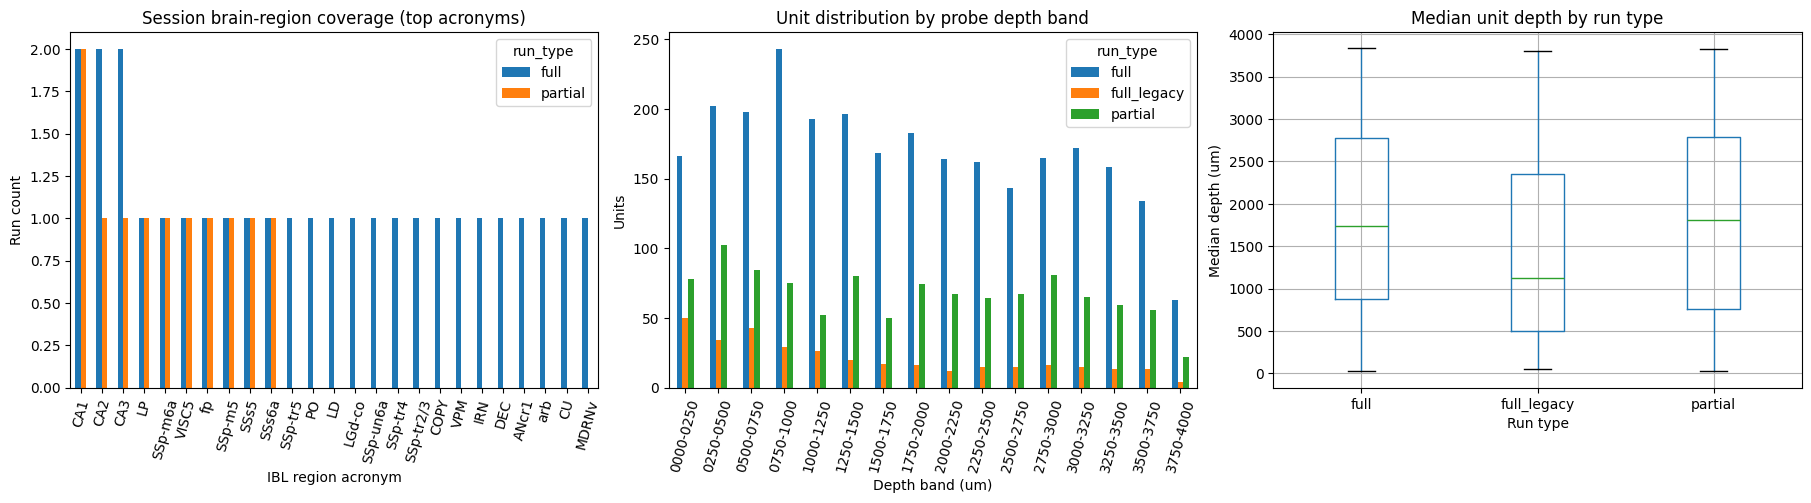

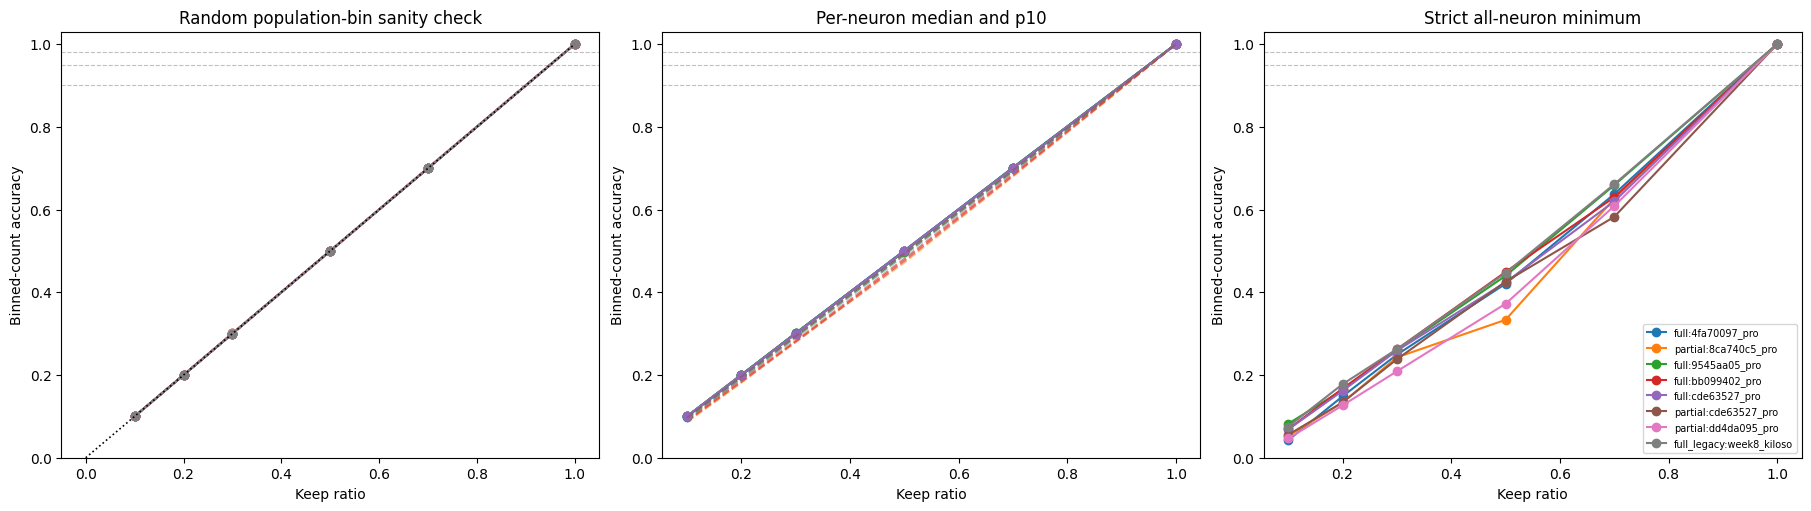

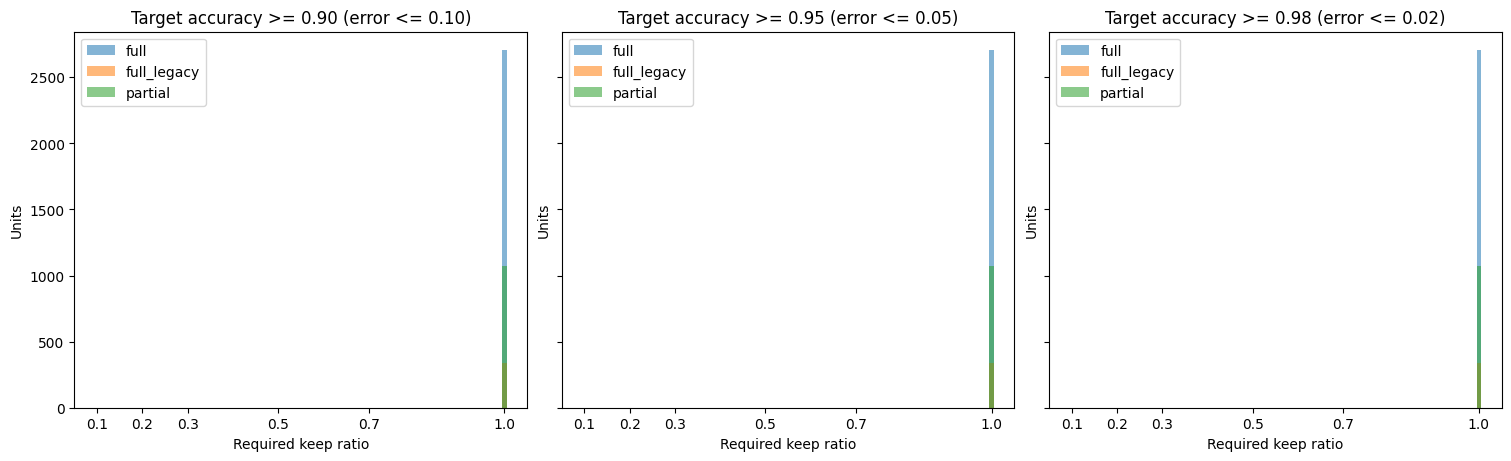

saved figures:
G:\academic\week8_population_sensitivity\week8_population_region_depth_distribution.png
G:\academic\week8_population_sensitivity\week8_population_accuracy_curves.png
G:\academic\week8_population_sensitivity\week8_population_keep_ratio_distribution.png


In [4]:
# Population sensitivity analysis over original full Kilosort outputs and partial-data Kilosort outputs.
from pathlib import Path
import csv
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('G:/academic')
FULL_RUN_ROOT = ROOT / 'week8_kilosort4_runs'
LEGACY_FULL_ROOT = ROOT / 'week8_kilosort4'
PARTIAL_RUN_ROOT = ROOT / 'week8_partial_kilosort4_runs'
OUT_DIR = ROOT / 'week8_population_sensitivity'
OUT_DIR.mkdir(parents=True, exist_ok=True)
EID_DIRECTORY_CSV = ROOT / 'ibl_viz_ss_2024-05-06' / 'eid_directory.csv'

# Sensitivity settings. Keep these aligned with the week5/week7 convention.
KEEP_RATIOS = [0.10, 0.20, 0.30, 0.50, 0.70, 1.00]
TARGET_ACCURACIES = [0.90, 0.95, 0.98]
BIN_SIZE_SAMPLES = 30000
MIN_SPIKES_PER_UNIT = 20
RNG_SEED = 20260713
FORCE_RECOMPUTE_TABLES = False  # Set True only when Kilosort outputs changed or you want to rebuild heavy per-unit tables.

UNIT_TABLE_CSV = OUT_DIR / 'week8_population_unit_table.csv'
UNIT_CURVE_CSV = OUT_DIR / 'week8_population_unit_accuracy_by_ratio.csv'
RUN_CURVE_CSV = OUT_DIR / 'week8_population_run_accuracy_by_ratio.csv'
REQUIRED_RATIO_CSV = OUT_DIR / 'week8_population_required_keep_ratio.csv'
RUN_INVENTORY_CSV = OUT_DIR / 'week8_population_run_inventory.csv'




def load_eid_region_table():
    if not EID_DIRECTORY_CSV.exists():
        return pd.DataFrame(columns=['eid', 'brain_region_acronyms', 'good_brain_region_acronyms'])
    cols = ['eid', 'brain_region_acronyms', 'good_brain_region_acronyms']
    table = pd.read_csv(EID_DIRECTORY_CSV, usecols=lambda c: c in cols)
    return table


EID_REGION_TABLE = load_eid_region_table()
EID_REGION_MAP = {
    row['eid']: {
        'brain_region_acronyms': row.get('brain_region_acronyms', ''),
        'good_brain_region_acronyms': row.get('good_brain_region_acronyms', ''),
    }
    for _, row in EID_REGION_TABLE.iterrows()
}


def session_regions_for_eid(eid, good_only=False):
    entry = EID_REGION_MAP.get(eid, {})
    key = 'good_brain_region_acronyms' if good_only else 'brain_region_acronyms'
    value = entry.get(key, '')
    if pd.isna(value):
        return []
    return [x for x in str(value).split(';') if x]

def read_tsv(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path, sep='\t')


def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding='utf-8'))


def maybe_float(value, default=np.nan):
    try:
        return float(value)
    except Exception:
        return default


def parse_settings_fs(run_info, default=30000.0):
    settings = run_info.get('kilosort_settings') or run_info.get('partial_kilosort_settings') or {}
    return maybe_float(settings.get('fs'), default)


def infer_eid_probe_from_path(path):
    text = str(path)
    match = re.search(r'([0-9a-f]{8})_probe(\d+)', text, flags=re.I)
    eid_short = match.group(1) if match else ''
    probe = 'probe' + match.group(2) if match else ''
    return eid_short, probe


def discover_kilosort_runs():
    runs = []
    for info_path in sorted(FULL_RUN_ROOT.glob('*/run_info_kilosort4.json')):
        info = read_json(info_path)
        ks_dir = Path(info.get('kilosort_results_dir') or info_path.parent / 'kilosort4')
        if (ks_dir / 'spike_times.npy').exists():
            runs.append({
                'run_type': 'full',
                'run_label': info_path.parent.name,
                'run_dir': str(info_path.parent),
                'ks_dir': str(ks_dir),
                'eid': info.get('eid', ''),
                'probe': info.get('probe', ''),
                'fs': parse_settings_fs(info),
                'source_info': str(info_path),
            })
    # Older single full run folder used earlier in the notebook.
    for ks_dir in sorted(LEGACY_FULL_ROOT.glob('probe*/')):
        if (ks_dir / 'spike_times.npy').exists():
            eid_short, probe = infer_eid_probe_from_path(ks_dir)
            runs.append({
                'run_type': 'full_legacy',
                'run_label': 'week8_kilosort4_' + ks_dir.name,
                'run_dir': str(ks_dir.parent),
                'ks_dir': str(ks_dir),
                'eid': '',
                'probe': ks_dir.name,
                'fs': 30000.0,
                'source_info': '',
            })
    for info_path in sorted(PARTIAL_RUN_ROOT.glob('*/run_info_partial_kilosort4.json')):
        info = read_json(info_path)
        if info.get('partial_kilosort_status') != 'complete':
            continue
        ks_dir = Path(info.get('partial_kilosort_results_dir') or info_path.parent / 'kilosort4_partial')
        if (ks_dir / 'spike_times.npy').exists():
            runs.append({
                'run_type': 'partial',
                'run_label': info_path.parent.name,
                'run_dir': str(info_path.parent),
                'ks_dir': str(ks_dir),
                'eid': info.get('eid', ''),
                'probe': info.get('probe', ''),
                'fs': parse_settings_fs(info),
                'partial_seconds': maybe_float(info.get('partial_samples_written'), np.nan) / parse_settings_fs(info),
                'source_info': str(info_path),
            })
    # Deduplicate by ks_dir, preserving discovery order.
    dedup = []
    seen = set()
    for run in runs:
        key = str(Path(run['ks_dir']).resolve())
        if key not in seen:
            seen.add(key)
            dedup.append(run)
    return dedup




def latest_input_mtime(runs):
    candidates = []
    for run in runs:
        ks_dir = Path(run['ks_dir'])
        candidates.extend([
            ks_dir / 'spike_times.npy',
            ks_dir / 'spike_clusters.npy',
            Path(run['source_info']) if run.get('source_info') else None,
        ])
    candidates.append(EID_DIRECTORY_CSV if EID_DIRECTORY_CSV.exists() else None)
    existing = [path for path in candidates if path is not None and Path(path).exists()]
    if not existing:
        return 0.0
    return max(Path(path).stat().st_mtime for path in existing)


def heavy_cache_is_valid(runs):
    required_paths = [UNIT_TABLE_CSV, UNIT_CURVE_CSV, RUN_INVENTORY_CSV]
    if FORCE_RECOMPUTE_TABLES or not all(path.exists() for path in required_paths):
        return False
    cache_mtime = min(path.stat().st_mtime for path in required_paths)
    return cache_mtime >= latest_input_mtime(runs)


def build_run_curve_from_unit_curve(unit_curve):
    rows = []
    group_cols = ['run_label', 'run_type', 'eid', 'probe', 'ks_dir', 'ratio']
    for keys, grp in unit_curve.groupby(group_cols, dropna=False):
        run_label, run_type, eid, probe, ks_dir, ratio = keys
        neuron_acc = grp['neuron_binned_count_accuracy'].dropna()
        baseline = grp['baseline_spikes'].sum()
        kept = grp['kept_spikes'].sum()
        rows.append({
            'run_label': run_label,
            'run_type': run_type,
            'eid': eid,
            'probe': probe,
            'ks_dir': ks_dir,
            'ratio': ratio,
            'n_units': int(grp['cluster_id'].nunique()),
            'population_baseline_spikes': int(baseline),
            'population_kept_spikes': int(kept),
            'random_subsample_population_mean_bin_accuracy': float(kept / baseline) if baseline else np.nan,
            'mean_bin_accuracy': float(neuron_acc.mean()) if not neuron_acc.empty else np.nan,
            'median_neuron_accuracy': float(neuron_acc.median()) if not neuron_acc.empty else np.nan,
            'p10_neuron_accuracy': float(neuron_acc.quantile(0.10)) if not neuron_acc.empty else np.nan,
            'p90_neuron_accuracy': float(neuron_acc.quantile(0.90)) if not neuron_acc.empty else np.nan,
            'all_neuron_min_accuracy': float(neuron_acc.min()) if not neuron_acc.empty else np.nan,
            'all_neuron_fraction_ge_090': float((neuron_acc >= 0.90).mean()) if not neuron_acc.empty else np.nan,
            'all_neuron_fraction_ge_095': float((neuron_acc >= 0.95).mean()) if not neuron_acc.empty else np.nan,
            'all_neuron_fraction_ge_098': float((neuron_acc >= 0.98).mean()) if not neuron_acc.empty else np.nan,
        })
    return pd.DataFrame(rows)

def load_cluster_labels(ks_dir):
    group = read_tsv(Path(ks_dir) / 'cluster_group.tsv')
    kslabel = read_tsv(Path(ks_dir) / 'cluster_KSLabel.tsv')
    amp = read_tsv(Path(ks_dir) / 'cluster_Amplitude.tsv')
    contam = read_tsv(Path(ks_dir) / 'cluster_ContamPct.tsv')
    labels = pd.DataFrame()
    for frame in [group, kslabel, amp, contam]:
        if frame.empty:
            continue
        first = frame.columns[0]
        frame = frame.rename(columns={first: 'cluster_id'})
        labels = frame if labels.empty else labels.merge(frame, on='cluster_id', how='outer')
    return labels


def load_run_units(run):
    ks_dir = Path(run['ks_dir'])
    spike_times = np.load(ks_dir / 'spike_times.npy').astype(np.int64).ravel()
    spike_clusters = np.load(ks_dir / 'spike_clusters.npy').astype(np.int64).ravel()
    spike_positions_path = ks_dir / 'spike_positions.npy'
    spike_depth = None
    if spike_positions_path.exists():
        pos = np.load(spike_positions_path)
        if pos.ndim == 2 and pos.shape[1] >= 2:
            spike_depth = pos[:, 1]
    labels = load_cluster_labels(ks_dir)
    cluster_label_map = {}
    if not labels.empty:
        label_col = 'group' if 'group' in labels.columns else ('KSLabel' if 'KSLabel' in labels.columns else None)
        if label_col:
            cluster_label_map = dict(zip(labels['cluster_id'].astype(int), labels[label_col].astype(str)))

    units = []
    max_time = int(spike_times.max()) if spike_times.size else 0
    if spike_clusters.size == 0:
        return units, max_time

    order = np.argsort(spike_clusters, kind='mergesort')
    sorted_clusters = spike_clusters[order]
    change = np.r_[True, sorted_clusters[1:] != sorted_clusters[:-1], True]
    bounds = np.flatnonzero(change)

    for start_i, stop_i in zip(bounds[:-1], bounds[1:]):
        clu = int(sorted_clusters[start_i])
        group_index = order[start_i:stop_i]
        n_spikes = int(group_index.size)
        if n_spikes < MIN_SPIKES_PER_UNIT:
            continue
        times = spike_times[group_index]
        depth = float(np.nanmedian(spike_depth[group_index])) if spike_depth is not None and n_spikes else np.nan
        units.append({
            'run_label': run['run_label'],
            'run_type': run['run_type'],
            'eid': run.get('eid', ''),
            'probe': run.get('probe', ''),
            'ks_dir': str(ks_dir),
            'cluster_id': clu,
            'n_spikes': n_spikes,
            'firing_rate_hz': n_spikes / (max_time / run['fs']) if max_time > 0 else np.nan,
            'median_depth_um': depth,
            'depth_band_250um': f'{int(depth // 250 * 250):04d}-{int(depth // 250 * 250 + 250):04d}' if np.isfinite(depth) else 'unknown',
            'cluster_label': cluster_label_map.get(clu, 'unknown'),
            'session_brain_regions': ';'.join(session_regions_for_eid(run.get('eid', ''), good_only=False)),
            'session_good_brain_regions': ';'.join(session_regions_for_eid(run.get('eid', ''), good_only=True)),
            '_spike_times': times,
        })
    return units, max_time


def deterministic_keep_mask(n, ratio, seed):
    if ratio >= 1.0:
        return np.ones(n, dtype=bool)
    rng = np.random.default_rng(seed)
    return rng.random(n) < ratio


def unit_accuracy_curve(times, max_time, ratios, bin_size, seed_base):
    n_bins = max(1, int(math.ceil((max_time + 1) / bin_size)))
    baseline = np.bincount((times // bin_size).astype(np.int64), minlength=n_bins)
    active = baseline > 0
    total = int(baseline.sum())
    rows = []
    for ratio in ratios:
        mask = deterministic_keep_mask(len(times), ratio, seed_base + int(ratio * 1000))
        kept = times[mask]
        kept_counts = np.bincount((kept // bin_size).astype(np.int64), minlength=n_bins)
        # Since kept spikes are a subset of baseline spikes, min(baseline, kept)=kept. Keep min for symmetry.
        per_bin_acc = np.divide(np.minimum(baseline, kept_counts), baseline, out=np.full(n_bins, np.nan), where=active)
        matched = int(np.minimum(baseline, kept_counts).sum())
        rows.append({
            'ratio': ratio,
            'baseline_spikes': total,
            'kept_spikes': int(kept_counts.sum()),
            'matched_spikes_after_binning': matched,
            'neuron_binned_count_accuracy': matched / total if total else np.nan,
            'mean_active_bin_accuracy': float(np.nanmean(per_bin_acc)) if np.any(active) else np.nan,
            '_baseline_counts': baseline,
            '_kept_counts': kept_counts,
        })
    return rows


def summarize_run_sensitivity(run, units, max_time):
    unit_rows = []
    population_baseline_by_ratio = {ratio: None for ratio in KEEP_RATIOS}
    population_kept_by_ratio = {ratio: None for ratio in KEEP_RATIOS}
    for unit_idx, unit in enumerate(units):
        curves = unit_accuracy_curve(unit['_spike_times'], max_time, KEEP_RATIOS, BIN_SIZE_SAMPLES, RNG_SEED + unit_idx * 10007)
        for curve in curves:
            ratio = curve['ratio']
            population_baseline_by_ratio[ratio] = curve['_baseline_counts'].copy() if population_baseline_by_ratio[ratio] is None else population_baseline_by_ratio[ratio] + curve['_baseline_counts']
            population_kept_by_ratio[ratio] = curve['_kept_counts'].copy() if population_kept_by_ratio[ratio] is None else population_kept_by_ratio[ratio] + curve['_kept_counts']
            out = {k: v for k, v in unit.items() if not k.startswith('_')}
            out.update({k: v for k, v in curve.items() if not k.startswith('_')})
            unit_rows.append(out)
    unit_curve = pd.DataFrame(unit_rows)

    summary_rows = []
    for ratio in KEEP_RATIOS:
        base = population_baseline_by_ratio[ratio]
        kept = population_kept_by_ratio[ratio]
        if base is None:
            continue
        active = base > 0
        per_bin = np.divide(np.minimum(base, kept), base, out=np.full(base.shape, np.nan, dtype=float), where=active)
        ratio_unit = unit_curve[unit_curve['ratio'] == ratio]
        neuron_acc = ratio_unit['neuron_binned_count_accuracy'].dropna() if not ratio_unit.empty else pd.Series(dtype=float)
        summary_rows.append({
            'run_label': run['run_label'],
            'run_type': run['run_type'],
            'eid': run.get('eid', ''),
            'probe': run.get('probe', ''),
            'ks_dir': run['ks_dir'],
            'ratio': ratio,
            'n_units': len(units),
            'population_baseline_spikes': int(base.sum()),
            'population_kept_spikes': int(kept.sum()),
            # This random spike-subset proxy is mathematically expected to be close to ratio.
            # Keep it as a sanity check, not as the main sensitivity result.
            'random_subsample_population_mean_bin_accuracy': float(np.nanmean(per_bin)) if np.any(active) else np.nan,
            'mean_bin_accuracy': float(neuron_acc.mean()) if not neuron_acc.empty else np.nan,
            'median_neuron_accuracy': float(neuron_acc.median()) if not neuron_acc.empty else np.nan,
            'p10_neuron_accuracy': float(neuron_acc.quantile(0.10)) if not neuron_acc.empty else np.nan,
            'p90_neuron_accuracy': float(neuron_acc.quantile(0.90)) if not neuron_acc.empty else np.nan,
            'all_neuron_min_accuracy': float(neuron_acc.min()) if not neuron_acc.empty else np.nan,
            'all_neuron_fraction_ge_090': float((neuron_acc >= 0.90).mean()) if not neuron_acc.empty else np.nan,
            'all_neuron_fraction_ge_095': float((neuron_acc >= 0.95).mean()) if not neuron_acc.empty else np.nan,
            'all_neuron_fraction_ge_098': float((neuron_acc >= 0.98).mean()) if not neuron_acc.empty else np.nan,
        })
    run_curve = pd.DataFrame(summary_rows)
    return unit_curve, run_curve


def add_required_ratios(unit_curve, run_curve):
    required_rows = []
    for target in TARGET_ACCURACIES:
        for (run_label, cluster_id), grp in unit_curve.groupby(['run_label', 'cluster_id']):
            grp = grp.sort_values('ratio')
            ok = grp[grp['neuron_binned_count_accuracy'] >= target]
            first = ok.iloc[0] if not ok.empty else grp.iloc[-1]
            meta = grp.iloc[0]
            required_rows.append({
                'target_accuracy': target,
                'target_error': 1 - target,
                'constraint_mode': 'per_neuron_required_ratio',
                'run_label': run_label,
                'run_type': meta['run_type'],
                'eid': meta.get('eid', ''),
                'probe': meta.get('probe', ''),
                'cluster_id': int(cluster_id),
                'required_keep_ratio': float(first['ratio']),
                'feasible': bool(not ok.empty),
                'n_spikes': int(meta['n_spikes']),
                'firing_rate_hz': meta['firing_rate_hz'],
                'median_depth_um': meta['median_depth_um'],
                'depth_band_250um': meta['depth_band_250um'],
                'cluster_label': meta['cluster_label'],
            })
        for run_label, grp in run_curve.groupby('run_label'):
            grp = grp.sort_values('ratio')
            meta = grp.iloc[0]
            mean_ok = grp[grp['mean_bin_accuracy'] >= target]
            all_ok = grp[grp['all_neuron_min_accuracy'] >= target]
            required_rows.append({
                'target_accuracy': target,
                'target_error': 1 - target,
                'constraint_mode': 'mean_bin',
                'run_label': run_label,
                'run_type': meta['run_type'],
                'eid': meta.get('eid', ''),
                'probe': meta.get('probe', ''),
                'required_keep_ratio': float(mean_ok.iloc[0]['ratio']) if not mean_ok.empty else np.nan,
                'feasible': bool(not mean_ok.empty),
                'n_units': int(meta['n_units']),
            })
            required_rows.append({
                'target_accuracy': target,
                'target_error': 1 - target,
                'constraint_mode': 'all_neuron',
                'run_label': run_label,
                'run_type': meta['run_type'],
                'eid': meta.get('eid', ''),
                'probe': meta.get('probe', ''),
                'required_keep_ratio': float(all_ok.iloc[0]['ratio']) if not all_ok.empty else np.nan,
                'feasible': bool(not all_ok.empty),
                'n_units': int(meta['n_units']),
            })
    return pd.DataFrame(required_rows)


runs = discover_kilosort_runs()
print('discovered Kilosort runs:', len(runs))
for run in runs:
    print(run['run_type'], run['run_label'], run['ks_dir'])

if heavy_cache_is_valid(runs):
    print('Using cached heavy per-unit tables. Set FORCE_RECOMPUTE_TABLES=True to rebuild from .npy files.')
    unit_table = pd.read_csv(UNIT_TABLE_CSV)
    unit_curve = pd.read_csv(UNIT_CURVE_CSV)
    run_inventory = pd.read_csv(RUN_INVENTORY_CSV)
else:
    print('Rebuilding heavy per-unit tables from Kilosort outputs...')
    all_units = []
    all_unit_curves = []
    all_run_curves = []
    run_inventory_rows = []
    for run in runs:
        units, max_time = load_run_units(run)
        if not units:
            print('no units after MIN_SPIKES_PER_UNIT filter:', run['run_label'])
            continue
        unit_curve_one, _ = summarize_run_sensitivity(run, units, max_time)
        all_units.extend([{k: v for k, v in unit.items() if not k.startswith('_')} for unit in units])
        all_unit_curves.append(unit_curve_one)
        run_inventory_rows.append({**run, 'n_units': len(units), 'max_time_samples': max_time, 'duration_seconds': max_time / run['fs'] if run['fs'] else np.nan, 'session_brain_regions': ';'.join(session_regions_for_eid(run.get('eid', ''), good_only=False)), 'session_good_brain_regions': ';'.join(session_regions_for_eid(run.get('eid', ''), good_only=True))})

    if not all_unit_curves:
        raise RuntimeError('No Kilosort units found for population sensitivity analysis.')

    unit_table = pd.DataFrame(all_units)
    unit_curve = pd.concat(all_unit_curves, ignore_index=True)
    run_inventory = pd.DataFrame(run_inventory_rows)
    unit_table.to_csv(UNIT_TABLE_CSV, index=False)
    unit_curve.drop(columns=[c for c in unit_curve.columns if c.startswith('_')], errors='ignore').to_csv(UNIT_CURVE_CSV, index=False)
    run_inventory.to_csv(RUN_INVENTORY_CSV, index=False)
    print('saved heavy cached tables:', UNIT_TABLE_CSV, UNIT_CURVE_CSV, RUN_INVENTORY_CSV)

# Lightweight summaries and figures are regenerated from cached unit tables every run.
run_curve = build_run_curve_from_unit_curve(unit_curve)
required = add_required_ratios(unit_curve, run_curve)
run_curve.to_csv(RUN_CURVE_CSV, index=False)
required.to_csv(REQUIRED_RATIO_CSV, index=False)
print('saved lightweight summary CSV files to:', OUT_DIR)
print('NOTE: random_subsample_population_mean_bin_accuracy is expected to be nearly y=x because kept spikes are a Bernoulli subset of baseline spikes. Use per-neuron quantiles and all_neuron metrics for sensitivity interpretation.')

display(run_inventory[['run_type', 'run_label', 'eid', 'probe', 'n_units', 'duration_seconds']].sort_values(['run_type', 'run_label']))
display(run_curve.sort_values(['run_type', 'run_label', 'ratio']).head(20))
display(required[required['constraint_mode'].isin(['mean_bin', 'all_neuron'])].sort_values(['target_accuracy', 'run_type', 'run_label', 'constraint_mode']))

# Figure 1: session brain-region coverage plus unit depth distribution.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
region_rows = []
for _, row in run_inventory.iterrows():
    for region in str(row.get('session_good_brain_regions') or row.get('session_brain_regions') or '').split(';'):
        if region:
            region_rows.append({'run_type': row['run_type'], 'region': region})
region_df = pd.DataFrame(region_rows)
if not region_df.empty:
    top_regions = region_df['region'].value_counts().head(25).index
    region_plot = region_df[region_df['region'].isin(top_regions)].groupby(['region', 'run_type']).size().unstack(1, fill_value=0).loc[top_regions]
    region_plot.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Session brain-region coverage (top acronyms)')
    axes[0].set_xlabel('IBL region acronym')
    axes[0].set_ylabel('Run count')
    axes[0].tick_params(axis='x', rotation=75)
else:
    axes[0].text(0.5, 0.5, 'No eid_directory region metadata found', ha='center', va='center')
    axes[0].set_axis_off()
unit_table.groupby(['run_type', 'depth_band_250um']).size().unstack(0, fill_value=0).plot(kind='bar', ax=axes[1])
axes[1].set_title('Unit distribution by probe depth band')
axes[1].set_xlabel('Depth band (um)')
axes[1].set_ylabel('Units')
axes[1].tick_params(axis='x', rotation=75)
unit_table.boxplot(column='median_depth_um', by='run_type', ax=axes[2])
axes[2].set_title('Median unit depth by run type')
axes[2].set_xlabel('Run type')
axes[2].set_ylabel('Median depth (um)')
fig.suptitle('')
fig.savefig(OUT_DIR / 'week8_population_region_depth_distribution.png', dpi=180)
plt.show()

# Figure 2: accuracy curves. The random population-bin curve should lie near y=x by construction.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for run_label, grp in run_curve.groupby('run_label'):
    label = f"{grp['run_type'].iloc[0]}:{run_label[:12]}"
    axes[0].plot(grp['ratio'], grp['random_subsample_population_mean_bin_accuracy'], marker='o', label=label)
    axes[1].plot(grp['ratio'], grp['median_neuron_accuracy'], marker='o', label=label)
    axes[1].plot(grp['ratio'], grp['p10_neuron_accuracy'], linestyle='--', alpha=0.55)
    axes[2].plot(grp['ratio'], grp['all_neuron_min_accuracy'], marker='o', label=label)
axes[0].plot([0, 1], [0, 1], color='black', linestyle=':', linewidth=1.2, label='expected y=x')
for ax, title in zip(axes, ['Random population-bin sanity check', 'Per-neuron median and p10', 'Strict all-neuron minimum']):
    for target in TARGET_ACCURACIES:
        ax.axhline(target, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Keep ratio')
    ax.set_ylabel('Binned-count accuracy')
    ax.set_ylim(0, 1.03)
axes[2].legend(fontsize=7, loc='lower right')
fig.savefig(OUT_DIR / 'week8_population_accuracy_curves.png', dpi=180)
plt.show()

# Figure 3: required keep-ratio distribution for same error limits, per neuron.
per_neuron_req = required[required['constraint_mode'] == 'per_neuron_required_ratio'].copy()
fig, axes = plt.subplots(1, len(TARGET_ACCURACIES), figsize=(5 * len(TARGET_ACCURACIES), 4.5), sharey=True, constrained_layout=True)
if len(TARGET_ACCURACIES) == 1:
    axes = [axes]
for ax, target in zip(axes, TARGET_ACCURACIES):
    data = per_neuron_req[per_neuron_req['target_accuracy'] == target]
    for run_type, grp in data.groupby('run_type'):
        ax.hist(grp['required_keep_ratio'].dropna(), bins=np.array(KEEP_RATIOS + [1.01]) - 0.005, alpha=0.55, label=run_type)
    ax.set_title(f'Target accuracy >= {target:.2f} (error <= {1-target:.2f})')
    ax.set_xlabel('Required keep ratio')
    ax.set_ylabel('Units')
    ax.set_xticks(KEEP_RATIOS)
    ax.legend()
fig.savefig(OUT_DIR / 'week8_population_keep_ratio_distribution.png', dpi=180)
plt.show()

print('saved figures:')
for name in ['week8_population_region_depth_distribution.png', 'week8_population_accuracy_curves.png', 'week8_population_keep_ratio_distribution.png']:
    print(OUT_DIR / name)


### week8_population_region_depth_distribution.png

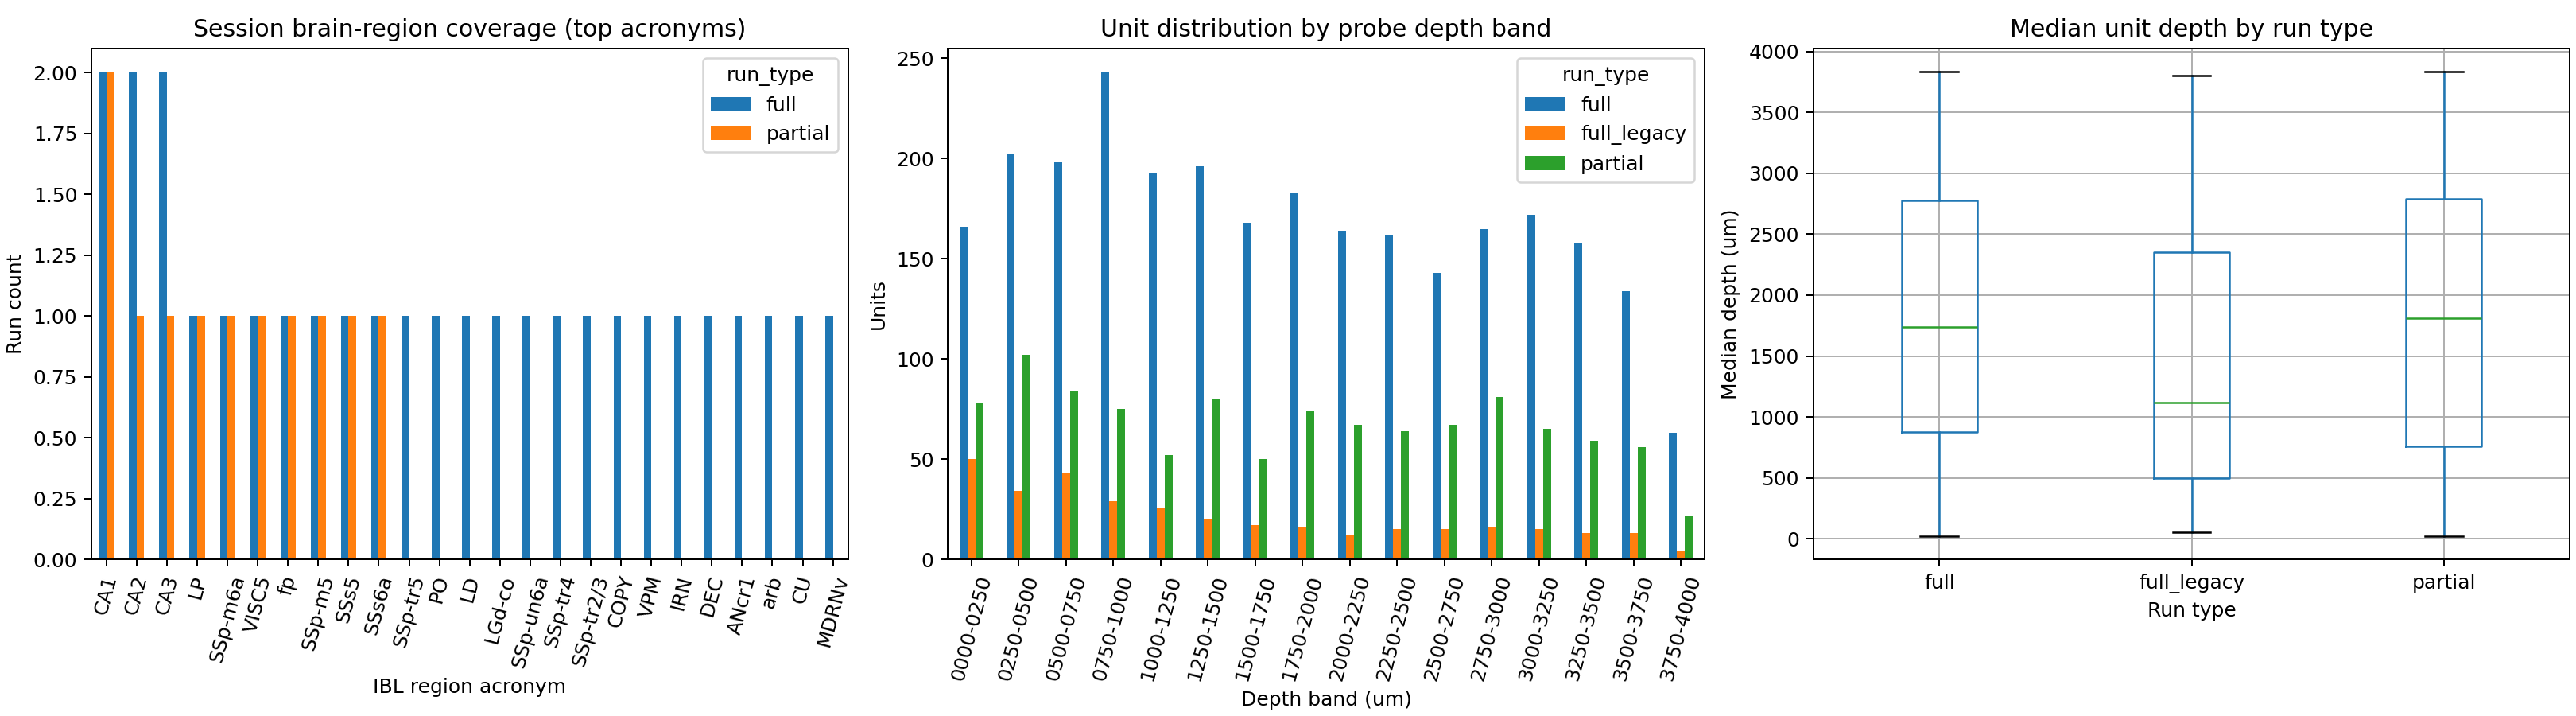

### week8_population_accuracy_curves.png

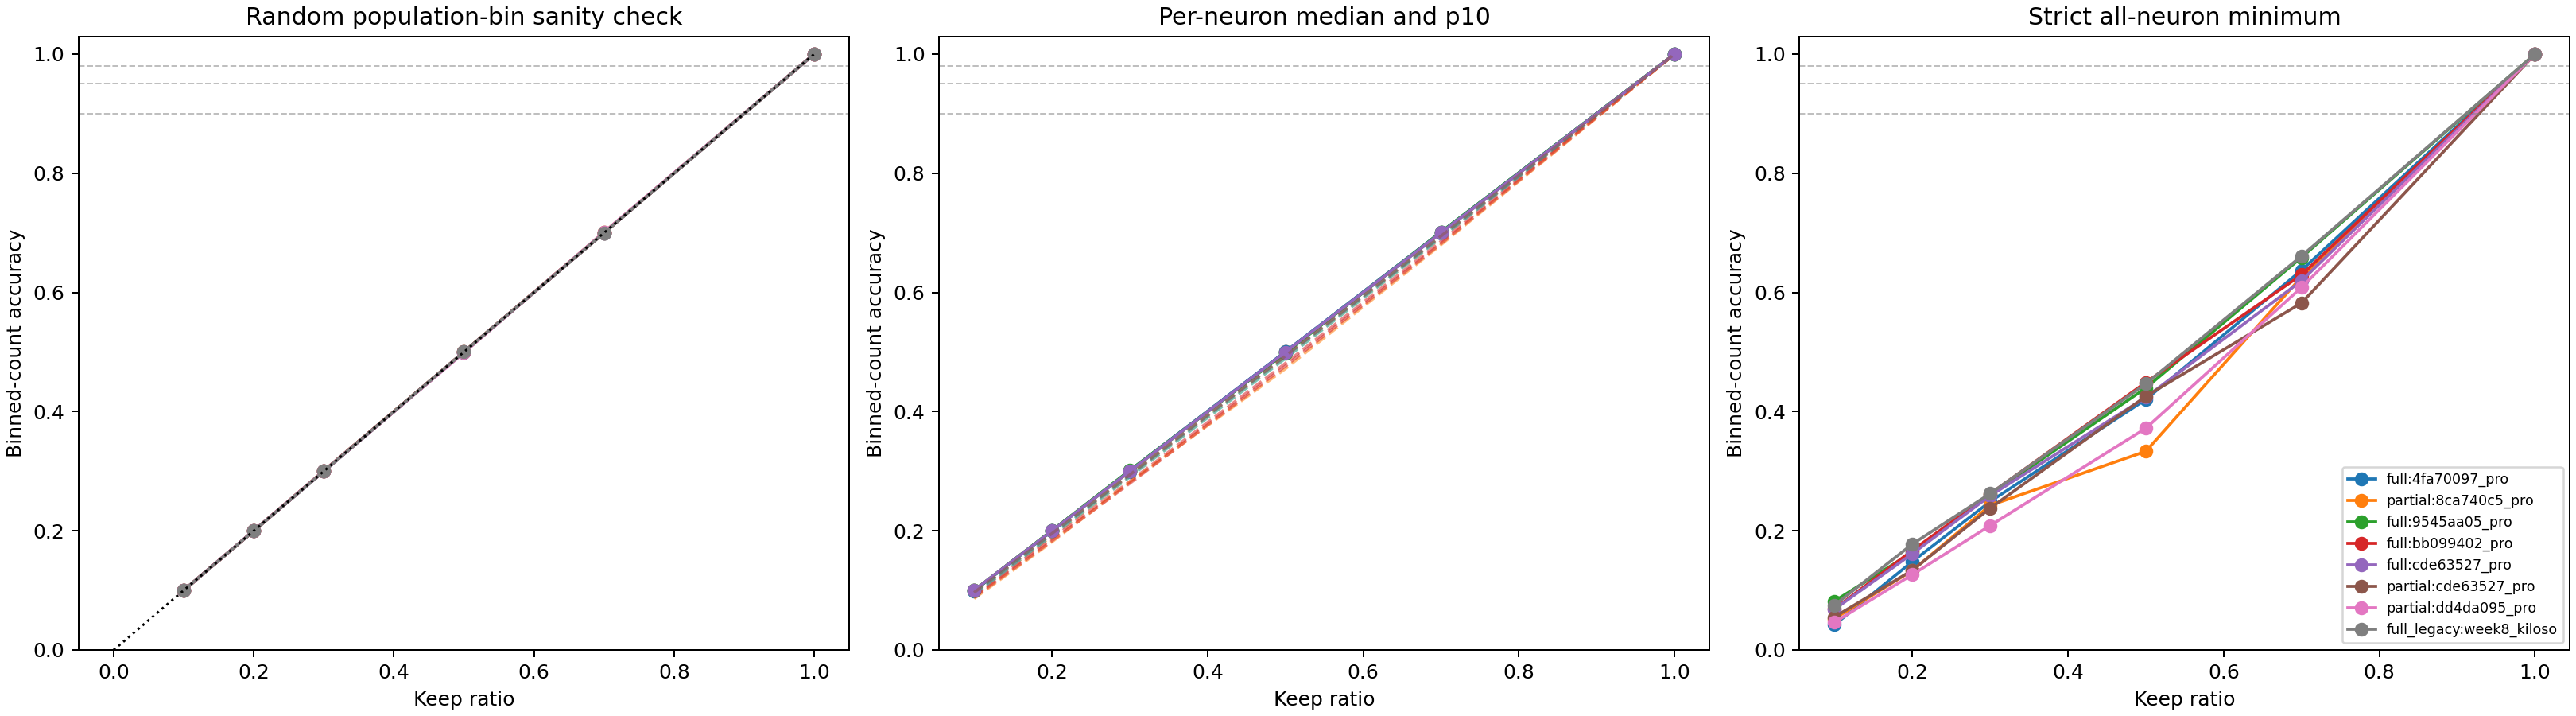

### week8_population_keep_ratio_distribution.png

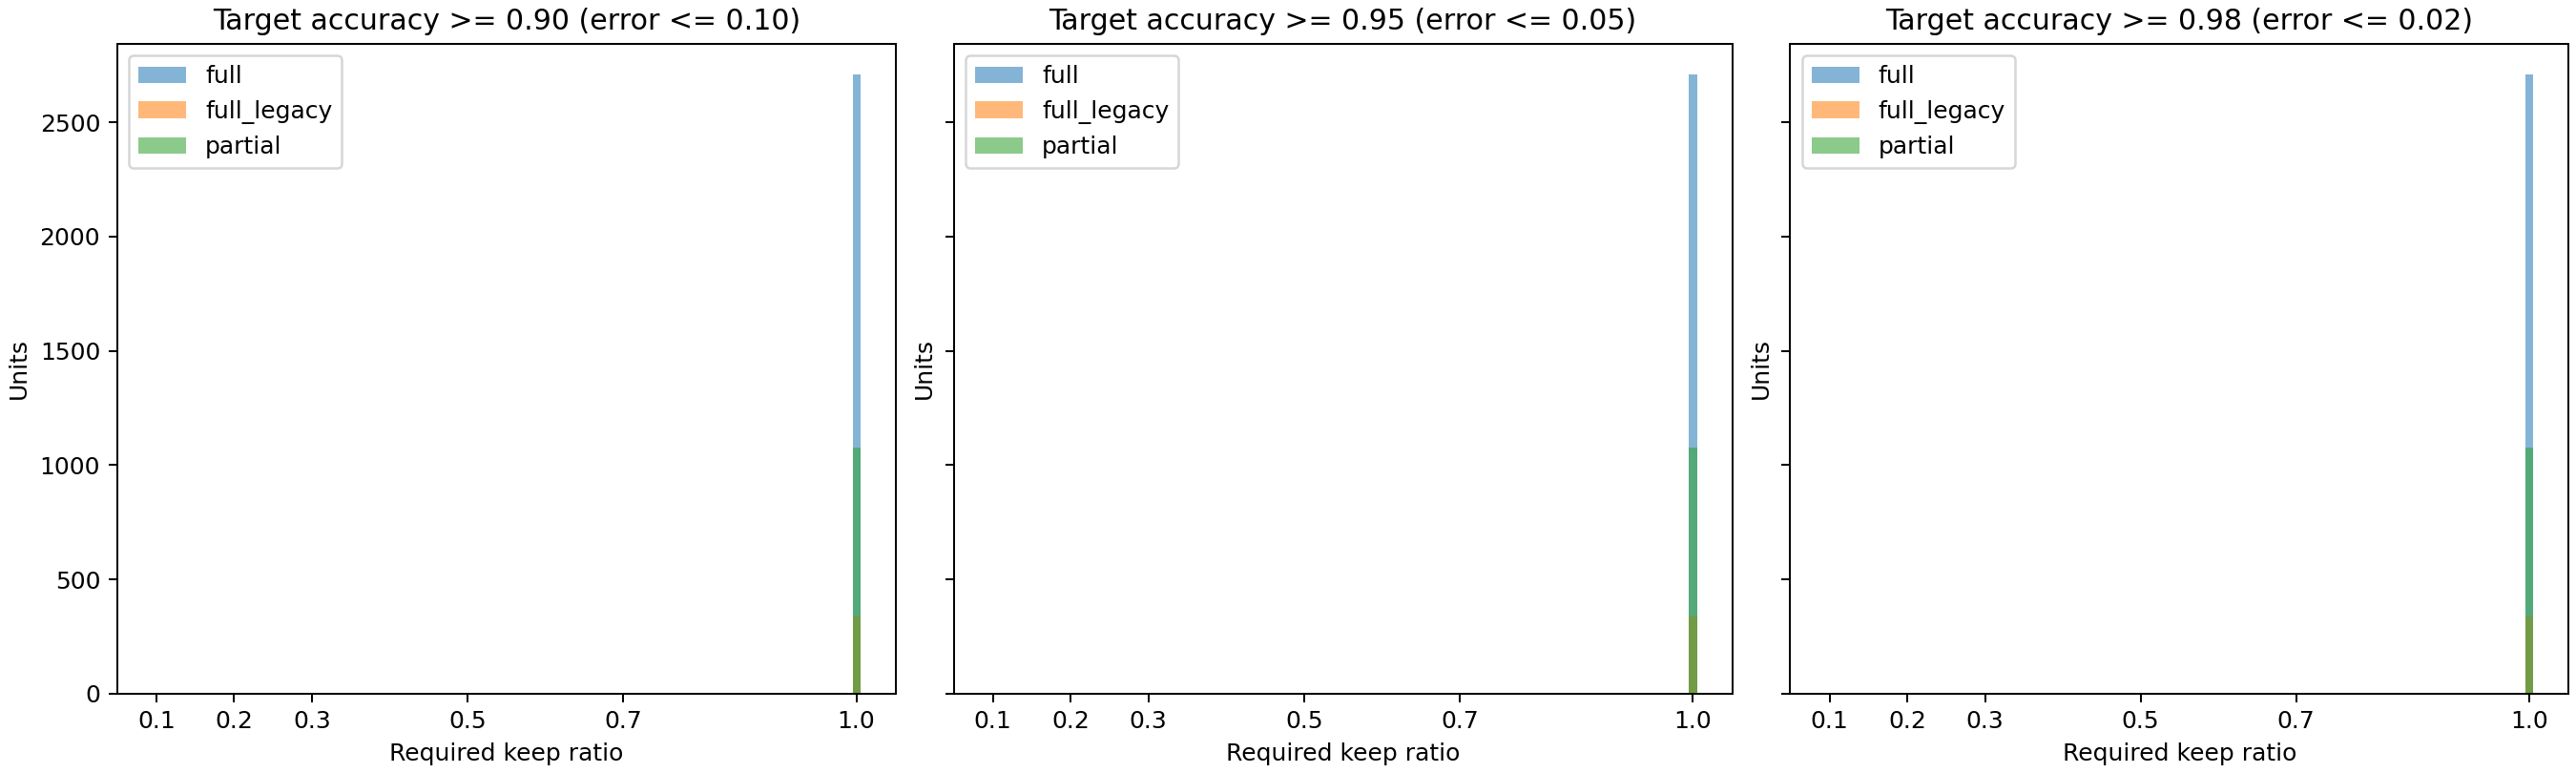

In [5]:
# Display population sensitivity figures generated by the previous cell inside the notebook.
from pathlib import Path
from IPython.display import Image, display, Markdown

OUT_DIR = Path('G:/academic/week8_population_sensitivity')
figure_files = [
    OUT_DIR / 'week8_partial_dct_accuracy_curves.png',
    OUT_DIR / 'week8_partial_dct_keep_ratio_distribution.png',
    OUT_DIR / 'week8_population_region_depth_distribution.png',
    OUT_DIR / 'week8_population_accuracy_curves.png',
    OUT_DIR / 'week8_population_keep_ratio_distribution.png',
]

missing = [path for path in figure_files if not path.exists()]
if missing:
    display(Markdown('**Missing figures. Run the population sensitivity analysis cell above first.**'))
    for path in missing:
        display(Markdown(f'- `{path}`'))
else:
    for path in figure_files:
        display(Markdown(f'### {path.name}'))
        display(Image(filename=str(path)))
